Group Number: BA1, Group22

Group Members:

- (Ellie) Jinglin Liu (13422688)

- Ananya Chenat (54988886)

- Hanyu Chen (99427189)

- Zhihan Zhang (54421615)

# Salary Prediction Tool — Improved Analysis

## 1. Setup and Data Loading

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.preprocessing import StandardScaler
import re
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 13})

df = pd.read_csv('postings.csv')
print(f'Total dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

Total dataset shape: (123849, 31)
Columns: ['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']


## 2. Data Cleaning

### 2.1 Filter to Salary Rows & Segment Representation

In [108]:
# Filter to rows with salary
df_salary = df[df['normalized_salary'].notna() & df['normalized_salary'] > 0].copy()
df_no_salary = df[df['normalized_salary'].isna()].copy()

print(f"Total rows:          {len(df):,}")
print(f"Rows WITH salary:    {len(df_salary):,}  ({len(df_salary)/len(df)*100:.1f}%)")
print(f"Rows WITHOUT salary: {len(df_no_salary):,} ({len(df_no_salary)/len(df)*100:.1f}%)")

# Segment representation
print("\n" + "="*60)
print("SEGMENT REPRESENTATION: salary subset vs. full dataset")
print("="*60)

for col in ['formatted_work_type', 'formatted_experience_level']:
    full_dist = df[col].value_counts(normalize=True, dropna=False).sort_index()
    sal_dist  = df_salary[col].value_counts(normalize=True, dropna=False).sort_index()
    compare = pd.DataFrame({
        'Full Dataset %': (full_dist * 100).round(1),
        'Salary Subset %': (sal_dist * 100).round(1),
    }).fillna(0)
    compare['Diff (pp)'] = (compare['Salary Subset %'] - compare['Full Dataset %']).round(1)
    print(f"\n--- {col} ---")
    print(compare.to_string())

print("\nConclusion: The salary subset is broadly representative. Full-time is")
print("slightly over-represented (+1.0 pp). No extreme biases detected.")

Total rows:          123,849
Rows WITH salary:    36,059  (29.1%)
Rows WITHOUT salary: 87,776 (70.9%)

SEGMENT REPRESENTATION: salary subset vs. full dataset

--- formatted_work_type ---
                     Full Dataset %  Salary Subset %  Diff (pp)
formatted_work_type                                            
Contract                        9.8             10.7        0.9
Full-time                      79.8             80.8        1.0
Internship                      0.8              0.7       -0.1
Other                           0.4              0.4        0.0
Part-time                       7.8              6.4       -1.4
Temporary                       1.0              1.1        0.1
Volunteer                       0.5              0.0       -0.5

--- formatted_experience_level ---
                            Full Dataset %  Salary Subset %  Diff (pp)
formatted_experience_level                                            
Associate                              7.9             10.8

### 2.2 Salary Cleaning

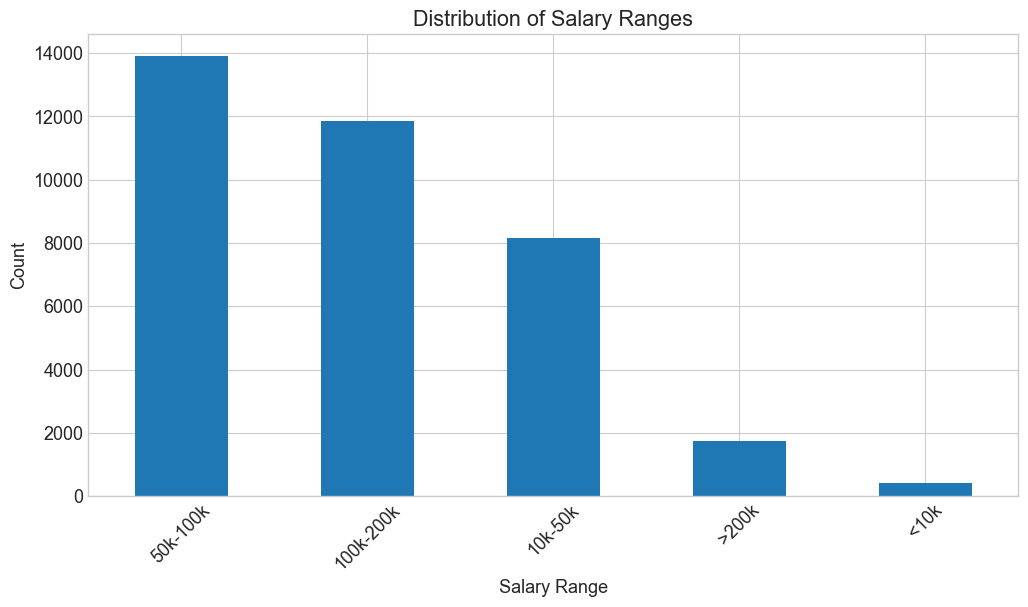

In [109]:
# minimum salary histogram (normalized_salary 10k, 10k-50k, 50k-100k, 100k-200k, >200k)
bins = [0, 10000, 50000, 100000, 200000, float('inf')]
labels = ['<10k', '10k-50k', '50k-100k', '100k-200k', '>200k']
df_salary['salary_range'] = pd.cut(df_salary['normalized_salary'], bins=bins, labels=labels)
df_salary['salary_range'].value_counts().plot(kind='bar', figsize=(12,6))
plt.title('Distribution of Salary Ranges')
plt.xlabel('Salary Range')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Job details for salary < 1k:


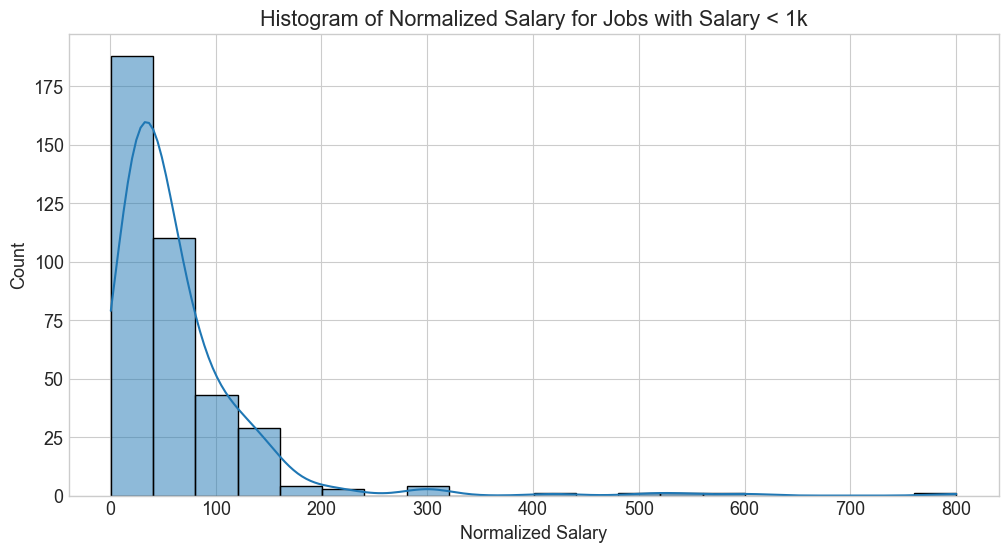

In [110]:
# list the job details of salary < 1k 
df_low_salary = df_salary[df_salary['normalized_salary'] < 1000]
print("Job details for salary < 1k:")

df_low_salary[['job_id', 'title', 'pay_period', 'max_salary', 'med_salary', 'min_salary', 'company_name', 'normalized_salary', 'location']]

# draw a histogram of salary < 1k job for normalized_salary
plt.figure(figsize=(12,6))
sns.histplot(df_low_salary['normalized_salary'], bins=20, kde=True)
plt.title('Histogram of Normalized Salary for Jobs with Salary < 1k')
plt.xlabel('Normalized Salary')
plt.ylabel('Count')
plt.show()


In [111]:
# some are hourly salary miscategorized as monthly
# job_id = 3887836853, 3890891699, 3904097388, 3904072394 -> change pay_period from MONTHLY to HOURLY, and recalculate the normalized_salary by multiplying the med_salary by 8 * 5 * 52 (assuming 50 weeks a year)

# job_id = 3884437239, should be 80,000
df_low_salary.sort_values('normalized_salary', ascending=False)[['job_id', 'title', 'pay_period', 'max_salary', 'med_salary', 'min_salary', 'company_name', 'normalized_salary', 'location']].head(10)

,job_id,title,pay_period,max_salary,med_salary,min_salary,company_name,normalized_salary,location
1545,3884437239,Seeking Hosts For Nonviolence Now Podcast,YEARLY,NaN,800.0,NaN,Pace e Bene Nonviolence Service & Campaign Non...,800.00,United States
13572,3887836853,Social Media Graphic Designer,MONTHLY,NaN,50.0,NaN,Sasas Mix,600.00,United States
23918,3890891699,GTM Program Manager (Partner Enablement),MONTHLY,51.54,NaN,38.65,Cypress HCM,541.14,"San Mateo, CA"
84131,3904097388,Senior Financial Analyst,MONTHLY,45.00,NaN,40.00,Find Great People | FGP,510.00,"Greenville, SC"
83569,3904072394,Commercial Plumber,MONTHLY,40.00,NaN,30.00,Rise Technical,420.00,"Indianapolis, IN"
75437,3903451511,Principal Wealth Manager - Investment Advisory,YEARLY,500.00,NaN,100.00,IT Resource Hunter,300.00,United States
75377,3903450536,Financial Advisor - wealth management,YEARLY,500.00,NaN,100.00,IT Resource Hunter,300.00,United States
68029,3902758366,Financial Advisor - wealth management,YEARLY,500.00,NaN,100.00,IT Resource Hunter,300.00,United States
67594,3902755685,Principal Wealth Manager - Investment Advisory,YEARLY,500.00,NaN,100.00,IT Resource Hunter,300.00,United States
48573,3901348261,Psychiatrist,YEARLY,250.00,NaN,200.00,Katie's Way Plus,225.00,"Washington, United States"


Job details for salary >= 1k and < 10k:


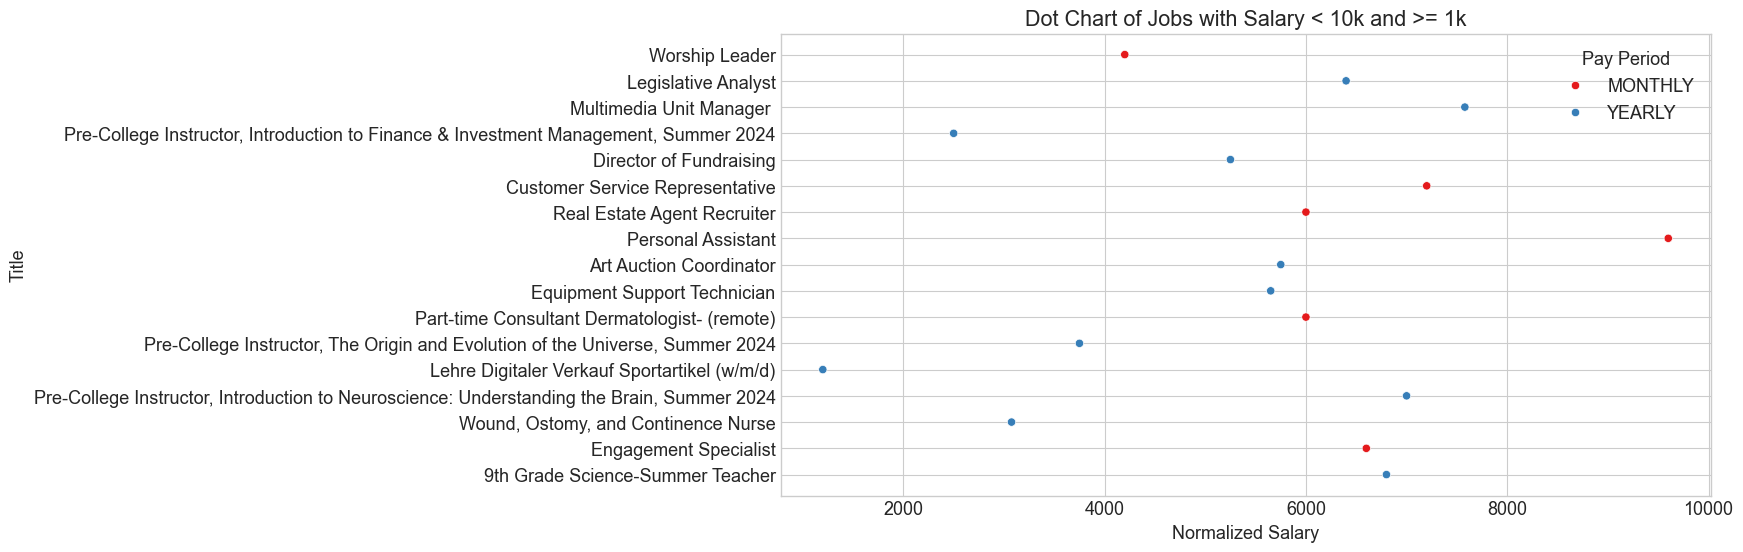

In [112]:
# list the job details of salary < 10k and salary >= 1k 
df_low_salary = df_salary[(df_salary['normalized_salary'] >= 1000) & (df_salary['normalized_salary'] < 10000)]
print("Job details for salary >= 1k and < 10k:")

df_low_salary[['job_id', 'title', 'pay_period', 'max_salary', 'med_salary', 'min_salary', 'company_name', 'normalized_salary', 'location']]

# plot a dot chart of salary < 10k and salary >= 1k jobs, x axis is normalized_salary, y axis is job_id, color by pay_period
plt.figure(figsize=(12,6))
sns.scatterplot(data=df_low_salary, x='normalized_salary', y='title', hue='pay_period', palette='Set1')
plt.title('Dot Chart of Jobs with Salary < 10k and >= 1k')
plt.xlabel('Normalized Salary')
plt.ylabel('Title')
plt.legend(title='Pay Period')
plt.show()

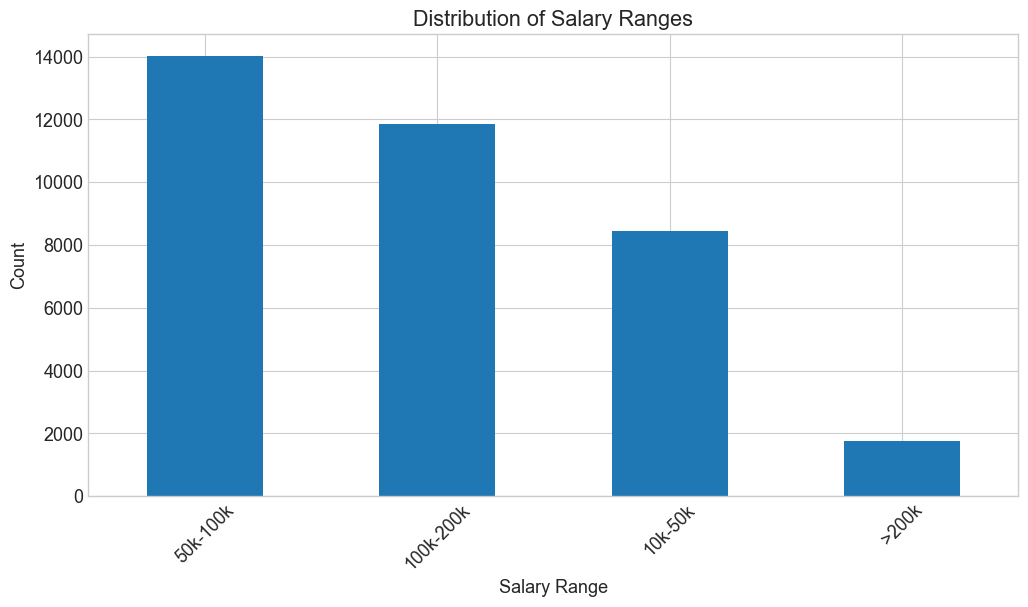

In [113]:
# some are hourly salary miscategorized as monthly
# job_id = 3887836853, 3890891699, 3904097388, 3904072394 -> change pay_period from MONTHLY to HOURLY, and recalculate the normalized_salary by multiplying the med_salary by 8 * 5 * 52 (assuming 50 weeks a year)
df_salary.loc[df_salary['job_id'].isin([3887836853, 3890891699, 3904097388, 3904072394]), 'pay_period'] = 'HOURLY'
df_salary.loc[df_salary['job_id'].isin([3887836853, 3890891699, 3904097388, 3904072394]), 'normalized_salary'] = df_salary.loc[df_salary['job_id'].isin([3887836853, 3890891699, 3904097388, 3904072394]), 'med_salary'] * 8 * 5 * 52

# job_id = 3884437239, should be times 10
df_salary.loc[df_salary['job_id'].isin([3884437239]), ['max_salary', 'med_salary', 'min_salary', 'normalized_salary']] *= 10

# job_id = 3884437239,3887473762,3891257272, should be times 100
df_salary.loc[df_salary['job_id'].isin([3887473762, 3891257272]), ['max_salary', 'med_salary', 'min_salary', 'normalized_salary']] *= 100

# job_id = 3894560863, should be YEARLY
df_salary.loc[df_salary['job_id'].isin([3894560863]), 'pay_period'] = 'YEARLY'
df_salary.loc[df_salary['job_id'].isin([3894560863]), 'normalized_salary'] = df_salary.loc[df_salary['job_id'].isin([3894560863]), 'med_salary']

# for low salary (normalized_salary < 1k) jobs, times 100 to the max_salary, med_salary, min_salary, and normalized_salary
df_salary.loc[df_salary['normalized_salary'] < 1000, ['max_salary', 'med_salary', 'min_salary', 'normalized_salary']] *= 100

# for low salary (normalized_salary >= 1k and < 10k) jobs, times 10 to the max_salary, med_salary, min_salary, and normalized_salary
df_salary.loc[(df_salary['normalized_salary'] >= 1000) & (df_salary['normalized_salary'] < 10000), ['max_salary', 'med_salary', 'min_salary', 'normalized_salary']] *= 10

# visualization of the normalized salary after correction, draw a histogram of normalized_salary all salary 
# minimum salary histogram (normalized_salary 10k, 10k-50k, 50k-100k, 100k-200k, >200k)
bins = [10000, 50000, 100000, 200000, float('inf')]
labels = ['10k-50k', '50k-100k', '100k-200k', '>200k']
df_salary['salary_range'] = pd.cut(df_salary['normalized_salary'], bins=bins, labels=labels)
df_salary['salary_range'].value_counts().plot(kind='bar', figsize=(12,6))
plt.title('Distribution of Salary Ranges')
plt.xlabel('Salary Range')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### 2.3 Narrow to Full-Time Postings
Focusing on full-time roles creates a more homogeneous dataset for salary comparison.

In [114]:
df_ft = df_salary[df_salary['formatted_work_type'] == 'Full-time'].copy()
print(f"Full-time postings with salary: {len(df_ft):,}")
print(f"  (dropped {len(df_salary) - len(df_ft):,} non-full-time rows)")

Full-time postings with salary: 29,131
  (dropped 6,928 non-full-time rows)


### 2.4 Clean Data Quality Issues

We only remove rows with clear **data quality issues** — not legitimate outliers:

1. **Mislabeled pay periods**: 232 rows marked `pay_period=YEARLY` have salary values like $22, $47, $55 — these are hourly rates accidentally coded as annual. They cause MAPE to explode (dividing by $22 gives 4000%+ error).
2. **Below minimum wage**: Any full-time salary below $15K/year (≈ $7.25/hour) is a data entry error.
3. **Above $1M**: Likely monthly/hourly rates miscoded as annual.

All other high-salary values are **kept** — the boxplots below show the remaining distribution with its natural outliers.

Data quality cleanup:
  Mislabeled YEARLY (hourly coded as annual): 0 removed
  Below $15K or above $1M: 104 removed
  Total removed: 104 (0.4%)
  Remaining: 29,027 rows

IQR stats: Q1=$55,000, Q3=$127,000, IQR=$72,000
Upper fence: $235,000
Points above upper fence: 825 (KEPT — legitimate high salaries)
Salary range: $15,000 — $950,000


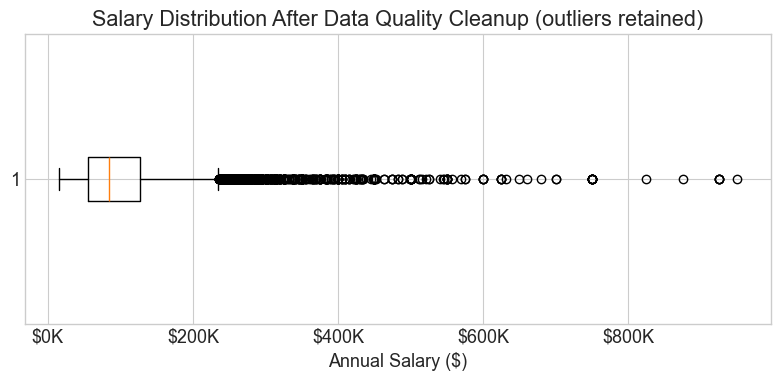

In [115]:
n_start = len(df_ft)

# 1. Remove mislabeled YEARLY (hourly rates coded as annual)
mislabeled = (df_ft['pay_period'] == 'YEARLY') & (df_ft['normalized_salary'] < 10000)
n_mislabeled = mislabeled.sum()
df_ft = df_ft[~mislabeled].copy()

# 2. Remove salaries outside valid range for full-time work
df_ft = df_ft[(df_ft['normalized_salary'] >= 15000) & (df_ft['normalized_salary'] <= 1_000_000)].copy()
n_removed = n_start - len(df_ft)

print(f"Data quality cleanup:")
print(f"  Mislabeled YEARLY (hourly coded as annual): {n_mislabeled} removed")
print(f"  Below $15K or above $1M: {n_removed - n_mislabeled} removed")
print(f"  Total removed: {n_removed} ({n_removed/n_start*100:.1f}%)")
print(f"  Remaining: {len(df_ft):,} rows")

# Boxplot showing remaining distribution with natural outliers
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(df_ft['normalized_salary'], vert=False)
ax.set_xlabel('Annual Salary ($)')
ax.set_title('Salary Distribution After Data Quality Cleanup (outliers retained)')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1000:.0f}K'))

q1 = df_ft['normalized_salary'].quantile(0.25)
q3 = df_ft['normalized_salary'].quantile(0.75)
iqr = q3 - q1
n_above_fence = (df_ft['normalized_salary'] > q3 + 1.5 * iqr).sum()
print(f"\nIQR stats: Q1=${q1:,.0f}, Q3=${q3:,.0f}, IQR=${iqr:,.0f}")
print(f"Upper fence: ${q3 + 1.5*iqr:,.0f}")
print(f"Points above upper fence: {n_above_fence:,} (KEPT — legitimate high salaries)")
print(f"Salary range: ${df_ft['normalized_salary'].min():,.0f} — ${df_ft['normalized_salary'].max():,.0f}")

plt.tight_layout()
plt.savefig('outlier_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [116]:
df_ft['formatted_experience_level'].value_counts()

formatted_experience_level
Mid-Senior level    10320
Entry level          7218
Associate            2923
Director             1203
Executive             359
Internship            195
Name: count, dtype: int64

### 2.5 Fix Experience Levels

195 rows have `Full-time` work type but `Internship` experience level — these are removed.

For the 23% of rows with missing experience level: the median salary ($80K) falls between Entry ($55K) and Mid-Senior ($107K), suggesting a mix of mid-level roles. We conservatively map these to `Mid-Senior level`.

In [117]:
print(f"\nExperience level distribution (before fix):")
print(df_ft['formatted_experience_level'].value_counts(dropna=False).to_string())


Experience level distribution (before fix):
formatted_experience_level
Mid-Senior level    10320
Entry level          7218
NaN                  6809
Associate            2923
Director             1203
Executive             359
Internship            195


In [118]:
# Remove Internship experience from full-time data
n_intern = (df_ft['formatted_experience_level'] == 'Internship').sum()
df_ft = df_ft[df_ft['formatted_experience_level'] != 'Internship'].copy()
print(f"Removed {n_intern} rows with Internship experience level")


# Fill na experience level based on job title keywords
# if experience is na, based on the title extract the seniority level (e.g. 'Senior', 'Junior', 'Mid', 'Entry', 'Director', 'associate') and fill the experience level accordingly, otherwise keep it as NaN 
def extract_experience_level(title):
    title = title.lower()
    if 'manager' in title or 'mid' in title:
        return 'Mid-Senior level'
    elif 'associate' in title or 'specialist' in title:
        return 'Associate'
    elif 'director' in title or 'partner' in title:
        return 'Director'
    elif 'entry' in title or 'junior' in title:
        return 'Entry level'
    else:
        return 'Associate'
df_ft['formatted_experience_level'] = df_ft.apply(lambda row: extract_experience_level(row['title']) if pd.isna(row['formatted_experience_level']) else row['formatted_experience_level'], axis=1)


print(f"\nExperience level distribution:")
print(df_ft['formatted_experience_level'].value_counts(dropna=False).to_string())

Removed 195 rows with Internship experience level

Experience level distribution:
formatted_experience_level
Mid-Senior level    11533
Associate            8140
Entry level          7276
Director             1524
Executive             359


### 2.6 Missing Values & Location


In [119]:
# Missing value analysis
key_features = ['remote_allowed', 'state_extracted', 'description',
                'skills_desc', 'closed_time']

df_ft['state'] = df_ft['location'].str.extract(r',\s*([A-Z]{2})$')[0]

print("Missing value analysis:")
print("="*55)
for col, actual_col in [('remote_allowed', 'remote_allowed'),
                         ('state', 'state'),
                         ('description', 'description'),
                         ('skills_desc', 'skills_desc'),
                         ('closed_time', 'closed_time')]:
    n_miss = df_ft[actual_col].isna().sum()
    pct = n_miss / len(df_ft) * 100
    flag = " ⚠️ >50% — excluded" if pct > 50 else (" ⚠️ elevated" if pct > 20 else " ✅")
    print(f"  {col:25s}: {n_miss:>6,} ({pct:5.1f}%){flag}")

# remote_allowed: NaN → 0 (not remote unless stated)
df_ft['remote_allowed'] = df_ft['remote_allowed'].fillna(0).astype(int)
print("\nImputation:")
print("  remote_allowed: NaN → 0 (assume not remote unless stated)")
print("  skills_desc: excluded (99% missing)")
print("  closed_time: excluded (99% missing)")

# Drop rows without state
n_before = len(df_ft)
df_ft = df_ft.dropna(subset=['state'])
print(f"  state: dropped {n_before - len(df_ft):,} rows missing state ({(n_before - len(df_ft))/(n_before)*100:.1f}%)")

print(f"\nDataset after cleaning: {len(df_ft):,} rows")

Missing value analysis:
  remote_allowed           : 25,156 ( 87.3%) ⚠️ >50% — excluded
  state                    :  4,978 ( 17.3%) ✅
  description              :      1 (  0.0%) ✅
  skills_desc              : 28,522 ( 98.9%) ⚠️ >50% — excluded
  closed_time              : 28,698 ( 99.5%) ⚠️ >50% — excluded

Imputation:
  remote_allowed: NaN → 0 (assume not remote unless stated)
  skills_desc: excluded (99% missing)
  closed_time: excluded (99% missing)
  state: dropped 4,978 rows missing state (17.3%)

Dataset after cleaning: 23,854 rows


### 2.7 Inflation Adjustment (2023-2024 → 2025-2026)


In [120]:
ANNUAL_INFLATION_RATE = 0.035  # approximate US CPI annual growth
YEARS_FORWARD = 2
INFLATION_FACTOR = (1 + ANNUAL_INFLATION_RATE) ** YEARS_FORWARD

df_ft['salary_adjusted'] = df_ft['normalized_salary'] * INFLATION_FACTOR

print(f"Inflation: {ANNUAL_INFLATION_RATE*100:.1f}% annual × {YEARS_FORWARD} years = {INFLATION_FACTOR:.4f}")
print(f"Original  — Median: ${df_ft['normalized_salary'].median():,.0f}, Mean: ${df_ft['normalized_salary'].mean():,.0f}")
print(f"Adjusted  — Median: ${df_ft['salary_adjusted'].median():,.0f}, Mean: ${df_ft['salary_adjusted'].mean():,.0f}")
print(f"\n→ All modeling uses inflation-adjusted salary as the target.")

Inflation: 3.5% annual × 2 years = 1.0712
Original  — Median: $80,000, Mean: $95,167
Adjusted  — Median: $85,698, Mean: $101,946

→ All modeling uses inflation-adjusted salary as the target.


### 2.7 employee_count & follower_count

In [121]:
df_employee_counts = pd.read_csv('employee_counts.csv')

# find df_employee_counts latest employee count for each company_id
df_employee_counts = df_employee_counts.sort_values('time_recorded', ascending=False).drop_duplicates('company_id')

# join df_employee_counts with df on company_id
df_ft = df_ft.merge(df_employee_counts, on='company_id', how='left')
print(f'After merging employee counts, dataset shape: {df_ft.shape}')

# # check for missing values in employee_count
print(f'Missing employee counts: {df_ft["employee_count"].isnull().sum()}')
print(f'Missing follower counts: {df_ft["follower_count"].isnull().sum()}')

# For rows with missing employee_count and follower_count, fill with the median employee count and follower count
df_ft['employee_count'] = df_ft['employee_count'].fillna(df_ft['employee_count'].median())
df_ft['follower_count'] = df_ft['follower_count'].fillna(df_ft['follower_count'].median())

After merging employee counts, dataset shape: (23854, 37)
Missing employee counts: 287
Missing follower counts: 287


### 2.8 Industry

In [122]:
# Join industry data on company_id
df_industry = pd.read_csv('company_industries.csv')

# join df_industry with df on company_id
df_ft = df_ft.merge(df_industry, on='company_id', how='left')
print(f'After merging industry data, dataset shape: {df_ft.shape}')

# check for missing values in industry
print(f'Missing industry: {df_ft["industry"].isnull().sum()}')

# For rows with missing employee_count and follower_count, fill with the median employee count and follower count
df_ft['industry'] = df_ft['industry'].fillna('Other')

After merging industry data, dataset shape: (23877, 38)
Missing industry: 313


In [123]:
cat_counts = df_ft['industry'].value_counts()
other_pct = cat_counts.get('Other', 0) / len(df_ft) * 100
classified_pct = 100 - other_pct

print(f"Industry: {df_ft['industry'].nunique()} groups ({classified_pct:.0f}% classified, {other_pct:.0f}% 'Other')")
print(f"\nIndustry distribution:")
for cat, count in cat_counts.items():
    pct = count / len(df_ft) * 100
    print(f"  {cat:25s}: {count:>5,} ({pct:4.1f}%)")

Industry: 137 groups (99% classified, 1% 'Other')

Industry distribution:
  Staffing and Recruiting  : 5,186 (21.7%)
  Hospitals and Health Care: 2,281 ( 9.6%)
  IT Services and IT Consulting: 1,357 ( 5.7%)
  Software Development     : 1,203 ( 5.0%)
  Financial Services       : 1,028 ( 4.3%)
  Retail                   : 1,002 ( 4.2%)
  Government Administration:   563 ( 2.4%)
  Non-profit Organizations :   436 ( 1.8%)
  Truck Transportation     :   426 ( 1.8%)
  Higher Education         :   416 ( 1.7%)
  Banking                  :   406 ( 1.7%)
  Hospitality              :   403 ( 1.7%)
  Real Estate              :   364 ( 1.5%)
  Food and Beverage Services:   351 ( 1.5%)
  Construction             :   339 ( 1.4%)
  Insurance                :   329 ( 1.4%)
  Other                    :   313 ( 1.3%)
  Advertising Services     :   295 ( 1.2%)
  Business Consulting and Services:   273 ( 1.1%)
  Telecommunications       :   258 ( 1.1%)
  Food and Beverage Manufacturing:   257 ( 1.1%)
  Def

## 3. Feature Engineering

### 3.1 Enrich Remote Flag from Job Descriptions

Since 87% of `remote_allowed` was NaN (filled with 0), we scan descriptions for remote keywords to recover missing information.

In [124]:
remote_keywords = [
    r'\bremote\b', r'\bwork from home\b', r'\bwfh\b',
    r'\btelecommute\b', r'\btelecommuting\b',
    r'\bfully remote\b', r'\bhybrid\b', r'\bvirtual position\b'
]
remote_pattern = '|'.join(remote_keywords)

df_ft['desc_mentions_remote'] = df_ft['description'].str.contains(
    remote_pattern, case=False, na=False
).astype(int)

originally_remote = df_ft['remote_allowed'].sum()
df_ft['remote_allowed'] = np.where(
    (df_ft['remote_allowed'] == 0) & (df_ft['desc_mentions_remote'] == 1),
    1, df_ft['remote_allowed']
)
newly_remote = df_ft['remote_allowed'].sum() - originally_remote

print(f"Originally flagged as remote:      {int(originally_remote):,}")
print(f"Upgraded via description keywords:  {int(newly_remote):,}")
print(f"Total remote after enrichment:     {int(df_ft['remote_allowed'].sum()):,} ({df_ft['remote_allowed'].mean()*100:.1f}%)")

Originally flagged as remote:      1,140
Upgraded via description keywords:  3,704
Total remote after enrichment:     4,844 (20.3%)


### 3.2 Job Title Categories

Raw job titles are too granular (thousands of unique values). We map them to **24 broad categories** using keyword matching, which covers ~78% of rows. The remaining 22% go into 'Other'.

In [125]:
def categorize_title(title):
    """Map job title to broad category using keywords."""
    if pd.isna(title):
        return 'Other'
    t = str(title).lower()

    # More specific patterns first
    if re.search(r'nurse|nursing|rn\b|lpn\b|cna\b|phlebotom|medical assist|dental', t):
        return 'Healthcare/Clinical/Nursing'
    if re.search(r'physician|doctor|surgeon|psychiatr|therapist|pharmacist|clinical|veterinarian|health|pathologist', t):
        return 'Healthcare/Clinical/Nursing'
    if re.search(r'software|developer|programmer|swe\b|full.?stack|front.?end|back.?end|architect', t):
        return 'Software/Dev/IT/DevOps'
    if re.search(r'data scien|data engineer|machine learn|ml engineer|ai engineer', t):
        return 'Data/ML/Analyst'
    if re.search(r'data analyst|business analyst|analyst|analytics|data', t):
        return 'Data/ML/Analyst'
    if re.search(r'account\s*executive|sales\s*(rep|manager|director|associate)|business develop|sale|auto detailer', t):
        return 'Sales'
    if re.search(r'marketing|brand|seo|content|social media|digital market', t):
        return 'Marketing'
    if re.search(r'financ|accountant|accounting|controller|cpa\b|tax\b|audit|accounts|account|payroll|bookkeeper|billing|invest|teller', t):
        return 'Finance/Accounting'
    if re.search(r'project manag|program manag|scrum|agile|pmo', t):
        return 'Project Management'
    if re.search(r'product manager|product owner|product director', t):
        return 'Product/Design/UX'
    if re.search(r'human resource|hr\b|recruiter|recruiting|talent acquis', t):
        return 'HR/Recruiting'
    if re.search(r'engineer|mechanic|technician|maintenance|electrician|hvac|plumb|construction|contruct|handler|assemble|estimator|custodian|machine|operator|quality|cnc|weldor', t):
        return 'Engineering/Trades'
    if re.search(r'design|ux|ui\b|graphic|creative', t):
        return 'Product/Design/UX'
    if re.search(r'admin|assistant|coordinator|receptionist|clerk|secretary|office|desk', t):
        return 'Administrative'
    if re.search(r'manager|director|vp\b|vice president|general manager|supervisor', t):
        return 'Management/Director'
    if re.search(r'customer service|support|helpdesk|call center|client', t):
        return 'Retail/Customer Service'
    if re.search(r'teacher|professor|instructor|tutor|education', t):
        return 'Education'
    if re.search(r'warehouse|logistics|supply chain|driver|delivery|shipping|buyer', t):
        return 'Logistics/Warehouse'
    if re.search(r'devops|sysadmin|system admin|network|infrastructure|cloud|it\b', t):
        return 'Software/Dev/IT/DevOps'
    if re.search(r'legal|attorney|lawyer|paralegal|compliance|litigation', t):
        return 'Legal'
    if re.search(r'cook|chef|restaurant|food|hospitality|hotel|housekeeper|janitor|serve', t):
        return 'Hospitality/Food'
    if re.search(r'consult', t):
        return 'Consulting'
    if re.search(r'retail|store|cashier|merchandis', t):
        return 'Retail/Customer Service'
    return 'Other'

df_ft['job_category'] = df_ft['title'].apply(categorize_title)

cat_counts = df_ft['job_category'].value_counts()
other_pct = cat_counts.get('Other', 0) / len(df_ft) * 100
classified_pct = 100 - other_pct

print(f"Job categories: {df_ft['job_category'].nunique()} groups ({classified_pct:.0f}% classified, {other_pct:.0f}% 'Other')")
print(f"\nCategory distribution:")
for cat, count in cat_counts.items():
    pct = count / len(df_ft) * 100
    print(f"  {cat:25s}: {count:>5,} ({pct:4.1f}%)")

Job categories: 19 groups (86% classified, 14% 'Other')

Category distribution:
  Engineering/Trades       : 3,776 (15.8%)
  Other                    : 3,460 (14.5%)
  Management/Director      : 2,484 (10.4%)
  Healthcare/Clinical/Nursing: 2,267 ( 9.5%)
  Administrative           : 2,096 ( 8.8%)
  Finance/Accounting       : 2,067 ( 8.7%)
  Sales                    : 1,585 ( 6.6%)
  Data/ML/Analyst          : 1,334 ( 5.6%)
  Software/Dev/IT/DevOps   :   969 ( 4.1%)
  Retail/Customer Service  :   620 ( 2.6%)
  Logistics/Warehouse      :   590 ( 2.5%)
  Project Management       :   534 ( 2.2%)
  Marketing                :   410 ( 1.7%)
  Legal                    :   404 ( 1.7%)
  HR/Recruiting            :   394 ( 1.7%)
  Product/Design/UX        :   385 ( 1.6%)
  Hospitality/Food         :   204 ( 0.9%)
  Education                :   182 ( 0.8%)
  Consulting               :   116 ( 0.5%)


### 3.3 Skill Keywords from Job Descriptions

We extract 16 skill-related binary features from the `description` field.

In [126]:
skill_keywords = {
    'skill_python': r'\bpython\b',
    'skill_sql': r'\bsql\b',
    'skill_excel': r'\bexcel\b|\bspreadsheet\b',
    'skill_java': r'\bjava\b',
    'skill_javascript': r'\bjavascript\b|\bjs\b|\breact\b|\bangular\b|\bnode\.?js\b',
    'skill_cloud': r'\baws\b|\bazure\b|\bgcp\b|\bcloud\b',
    'skill_ml_ai': r'\bmachine learning\b|\bdeep learning\b|\bartificial intelligence\b|\bai\b|\bml\b',
    'skill_data_analysis': r'\bdata analysis\b|\banalytics\b|\btableau\b|\bpower bi\b',
    'skill_management': r'\bmanagement\b|\bmanaging\b|\bleadership\b|\bsupervis\b',
    'skill_communication': r'\bcommunication\b|\bpresentation\b|\binterpersonal\b',
    'skill_sales': r'\bsales\b|\bbusiness development\b|\bclient relation\b',
    'skill_finance': r'\bfinance\b|\baccounting\b|\bbudget\b|\bfinancial\b',
    'skill_healthcare': r'\bnursing\b|\bpatient care\b|\bclinical\b|\bmedical\b|\bhipaa\b',
    'skill_engineering': r'\bengineering\b|\bcad\b|\bautocad\b|\bmechanical\b',
    'skill_marketing': r'\bmarketing\b|\bseo\b|\bcontent\b|\bsocial media\b|\bbrand\b',
    'skill_project_mgmt': r'\bproject management\b|\bpmp\b|\bagile\b|\bscrum\b',
}

for col_name, pattern in skill_keywords.items():
    df_ft[col_name] = df_ft['description'].str.contains(
        pattern, case=False, na=False
    ).astype(int)

print("Skill prevalence in full-time job descriptions:")
print("="*50)
for col_name in sorted(skill_keywords.keys(),
                        key=lambda c: df_ft[c].mean(), reverse=True):
    pct = df_ft[col_name].mean() * 100
    bar = '█' * int(pct / 2)
    print(f"  {col_name:25s}: {pct:5.1f}%  {bar}")

Skill prevalence in full-time job descriptions:
  skill_management         :  65.8%  ████████████████████████████████
  skill_communication      :  54.2%  ███████████████████████████
  skill_healthcare         :  49.6%  ████████████████████████
  skill_finance            :  36.8%  ██████████████████
  skill_sales              :  23.5%  ███████████
  skill_marketing          :  21.8%  ██████████
  skill_engineering        :  21.8%  ██████████
  skill_excel              :  17.8%  ████████
  skill_project_mgmt       :  12.5%  ██████
  skill_data_analysis      :   8.7%  ████
  skill_cloud              :   6.6%  ███
  skill_ml_ai              :   3.9%  █
  skill_sql                :   3.4%  █
  skill_python             :   3.4%  █
  skill_javascript         :   2.0%  
  skill_java               :   1.7%  


## 4. Updated Feature & Outcome Distributions

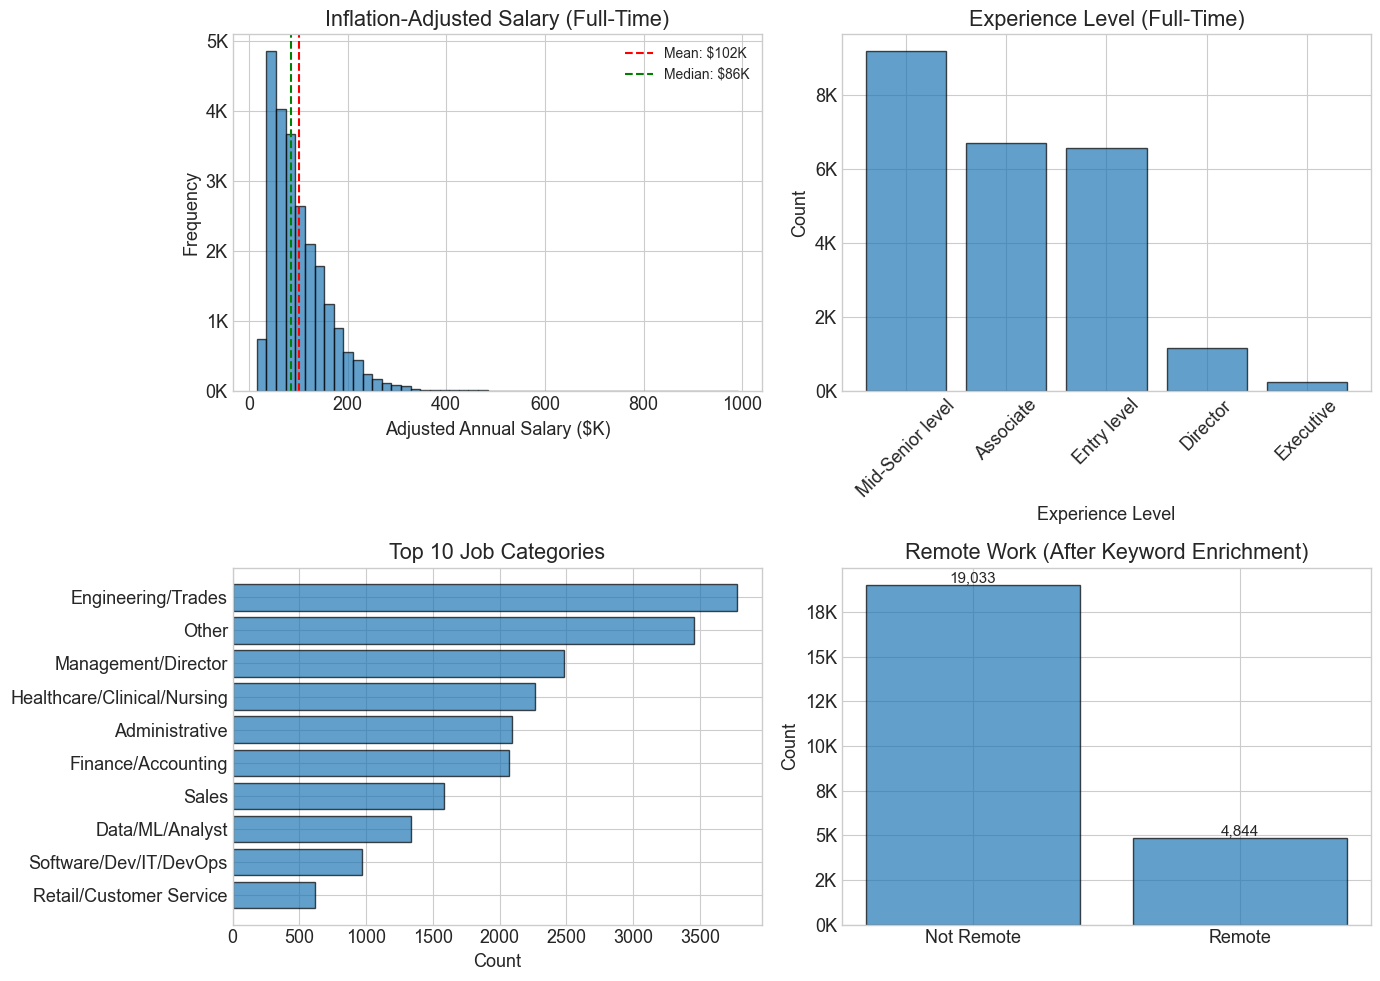

In [127]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Salary Distribution
ax1 = axes[0, 0]
ax1.hist(df_ft['salary_adjusted'] / 1000, bins=50, edgecolor='black', alpha=0.7)
ax1.axvline(df_ft['salary_adjusted'].mean() / 1000, color='red', linestyle='--',
            label=f'Mean: ${df_ft["salary_adjusted"].mean()/1000:.0f}K')
ax1.axvline(df_ft['salary_adjusted'].median() / 1000, color='green', linestyle='--',
            label=f'Median: ${df_ft["salary_adjusted"].median()/1000:.0f}K')
ax1.set_xlabel('Adjusted Annual Salary ($K)')
ax1.set_ylabel('Frequency')
ax1.set_title('Inflation-Adjusted Salary (Full-Time)')
ax1.legend(fontsize=10)

# 2. Experience Level
ax2 = axes[0, 1]
exp_counts = df_ft['formatted_experience_level'].value_counts()
ax2.bar(exp_counts.index, exp_counts.values, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Experience Level')
ax2.set_ylabel('Count')
ax2.set_title('Experience Level (Full-Time)')
ax2.tick_params(axis='x', rotation=45)

# 3. Top Job Categories
ax3 = axes[1, 0]
top_cats = df_ft['job_category'].value_counts().head(10)
ax3.barh(top_cats.index[::-1], top_cats.values[::-1], edgecolor='black', alpha=0.7)
ax3.set_xlabel('Count')
ax3.set_title('Top 10 Job Categories')

# 4. Remote
ax4 = axes[1, 1]
remote_counts = df_ft['remote_allowed'].value_counts()
labels = ['Not Remote', 'Remote']
vals = [remote_counts.get(0, 0), remote_counts.get(1, 0)]
ax4.bar(labels, vals, edgecolor='black', alpha=0.7)
ax4.set_ylabel('Count')
ax4.set_title('Remote Work (After Keyword Enrichment)')
for i, v in enumerate(vals):
    ax4.text(i, v + 100, f'{v:,}', ha='center', fontsize=11)

for ax in axes.flatten():
    if ax == ax3:
        continue  # skip x-axis formatting for horizontal bar chart
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

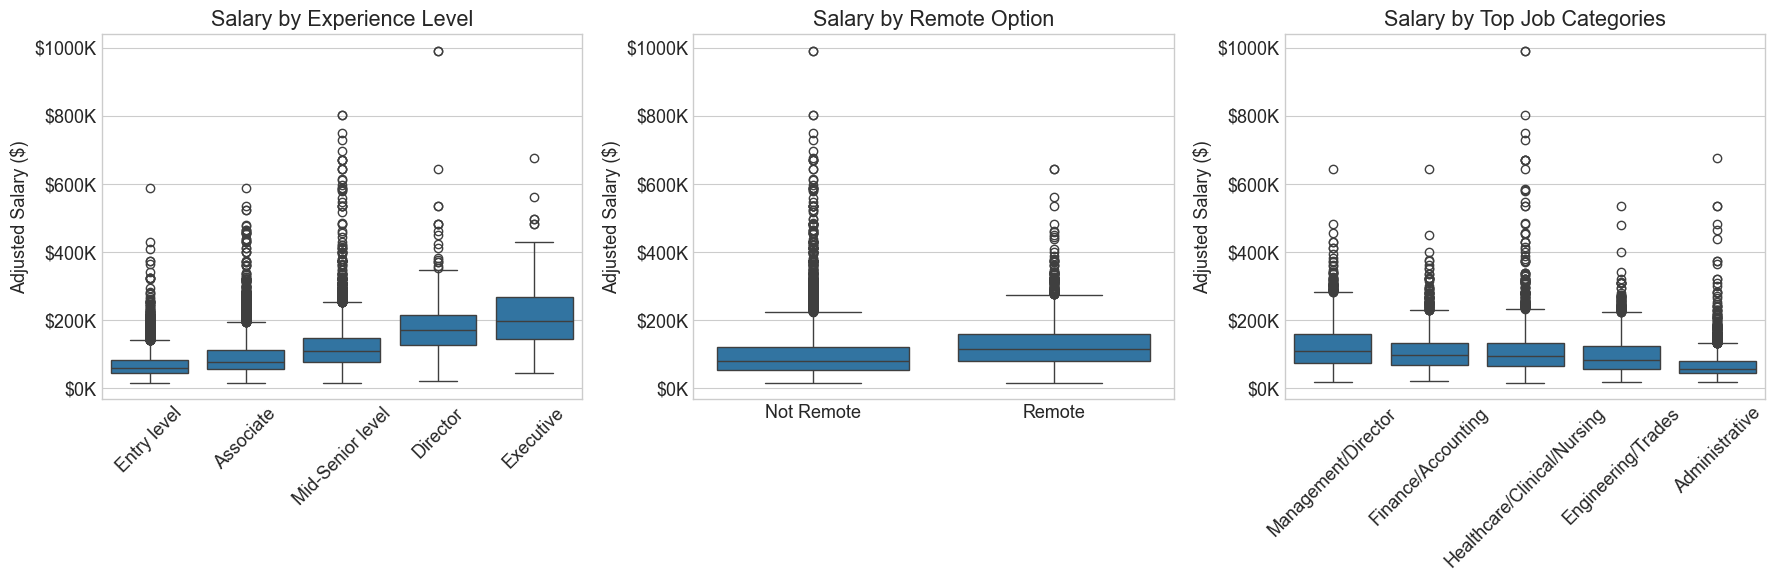

In [128]:
# Salary boxplots by key features
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# By Experience Level
exp_order = ['Entry level', 'Associate', 'Mid-Senior level', 'Director', 'Executive']
exp_order = [e for e in exp_order if e in df_ft['formatted_experience_level'].unique()]
sns.boxplot(data=df_ft, x='formatted_experience_level', y='salary_adjusted',
            order=exp_order, ax=axes[0])
axes[0].set_title('Salary by Experience Level')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# By Remote
df_ft['remote_label'] = df_ft['remote_allowed'].map({0: 'Not Remote', 1: 'Remote'})
sns.boxplot(data=df_ft, x='remote_label', y='salary_adjusted', ax=axes[1])
axes[1].set_title('Salary by Remote Option')
axes[1].set_xlabel('')

# By Top Job Categories
top_5_cats = df_ft['job_category'].value_counts().head(6).index.tolist()
if 'Other' in top_5_cats:
    top_5_cats.remove('Other')
top_5_cats = top_5_cats[:5]
df_top = df_ft[df_ft['job_category'].isin(top_5_cats)]
cat_order = df_top.groupby('job_category')['salary_adjusted'].median().sort_values(ascending=False).index
sns.boxplot(data=df_top, x='job_category', y='salary_adjusted', order=cat_order, ax=axes[2])
axes[2].set_title('Salary by Top Job Categories')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)

for ax in axes:
    ax.set_ylabel('Adjusted Salary ($)')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('salary_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

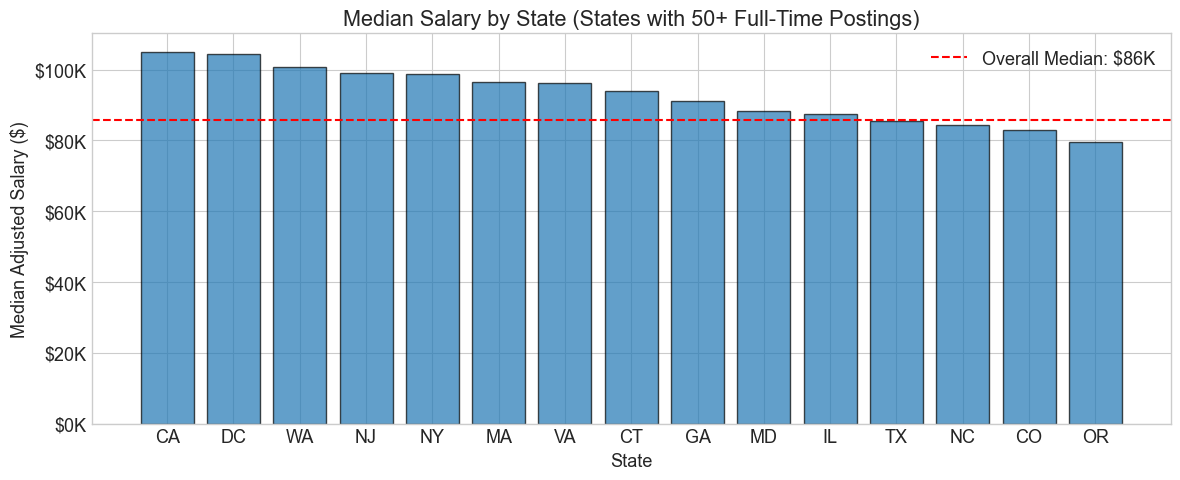

In [129]:
# Median salary by state (top 15)
fig, ax = plt.subplots(figsize=(12, 5))
state_salary = df_ft.groupby('state')['salary_adjusted'].agg(['median', 'count'])
state_salary = state_salary[state_salary['count'] >= 50].sort_values('median', ascending=False).head(15)
ax.bar(state_salary.index, state_salary['median'], edgecolor='black', alpha=0.7)
ax.axhline(df_ft['salary_adjusted'].median(), color='red', linestyle='--',
           label=f'Overall Median: ${df_ft["salary_adjusted"].median()/1000:.0f}K')
ax.set_xlabel('State')
ax.set_ylabel('Median Adjusted Salary ($)')
ax.set_title('Median Salary by State (States with 50+ Full-Time Postings)')
ax.legend()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('salary_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

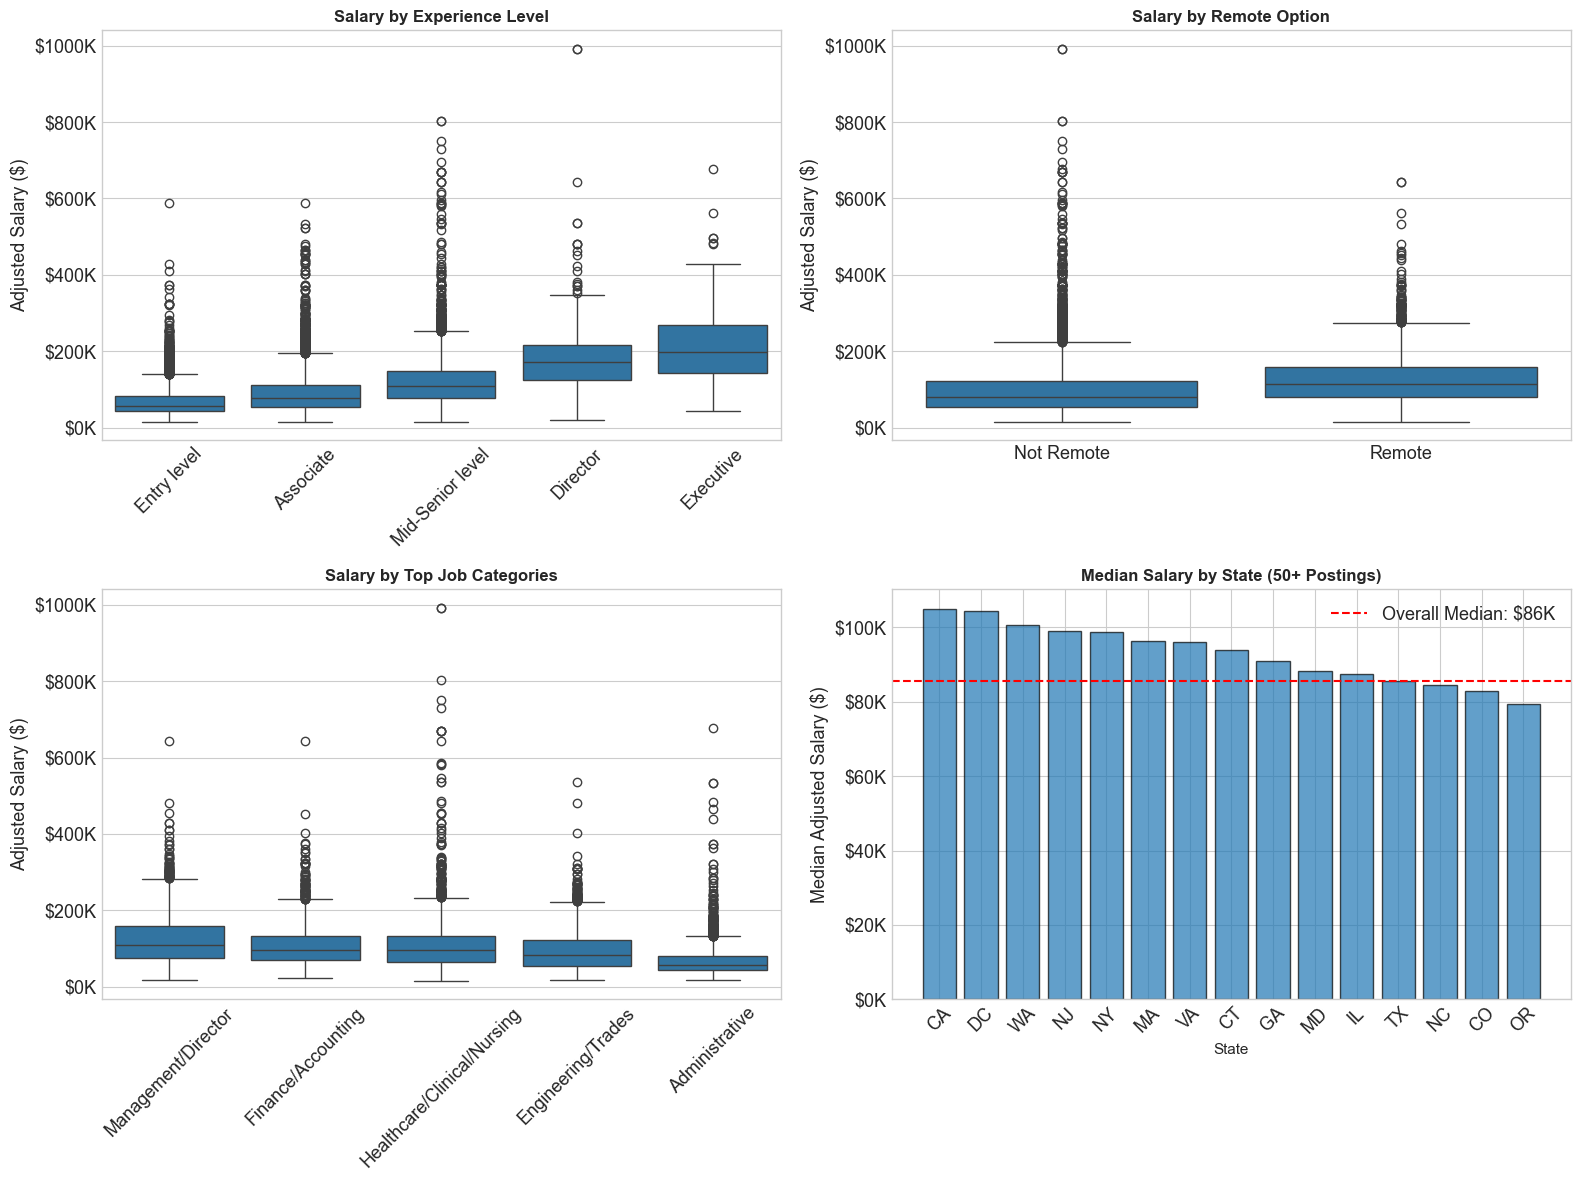

In [130]:
# Combine salary boxplots and median salary by state plots into 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Row 1: Three boxplots (spread across columns)
# By Experience Level
exp_order = ['Entry level', 'Associate', 'Mid-Senior level', 'Director', 'Executive']
exp_order = [e for e in exp_order if e in df_ft['formatted_experience_level'].unique()]
sns.boxplot(data=df_ft, x='formatted_experience_level', y='salary_adjusted',
            order=exp_order, ax=axes[0, 0])
axes[0, 0].set_title('Salary by Experience Level', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_ylabel('Adjusted Salary ($)')
axes[0, 0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1000:.0f}K'))

# By Remote
df_ft['remote_label'] = df_ft['remote_allowed'].map({0: 'Not Remote', 1: 'Remote'})
sns.boxplot(data=df_ft, x='remote_label', y='salary_adjusted', ax=axes[0, 1])
axes[0, 1].set_title('Salary by Remote Option', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Adjusted Salary ($)')
axes[0, 1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1000:.0f}K'))

# By Top Job Categories (bottom left)
top_5_cats = df_ft['job_category'].value_counts().head(6).index.tolist()
if 'Other' in top_5_cats:
    top_5_cats.remove('Other')
top_5_cats = top_5_cats[:5]
df_top = df_ft[df_ft['job_category'].isin(top_5_cats)]
cat_order = df_top.groupby('job_category')['salary_adjusted'].median().sort_values(ascending=False).index
sns.boxplot(data=df_top, x='job_category', y='salary_adjusted', order=cat_order, ax=axes[1, 0])
axes[1, 0].set_title('Salary by Top Job Categories', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].set_ylabel('Adjusted Salary ($)')
axes[1, 0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1000:.0f}K'))

# Median salary by state (top 15) - bottom right
state_salary = df_ft.groupby('state')['salary_adjusted'].agg(['median', 'count'])
state_salary = state_salary[state_salary['count'] >= 50].sort_values('median', ascending=False).head(15)
axes[1, 1].bar(state_salary.index, state_salary['median'], edgecolor='black', alpha=0.7)
axes[1, 1].axhline(df_ft['salary_adjusted'].median(), color='red', linestyle='--',
                    label=f'Overall Median: ${df_ft["salary_adjusted"].median()/1000:.0f}K')
axes[1, 1].set_xlabel('State', fontsize=11)
axes[1, 1].set_ylabel('Median Adjusted Salary ($)')
axes[1, 1].set_title('Median Salary by State (50+ Postings)', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('salary_analysis_combined.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Modeling

### 5.1 Prepare Features and Train/Test Split

In [131]:
skill_cols = list(skill_keywords.keys())
feature_cols = ['formatted_experience_level', 'remote_allowed', 'state',
                'job_category', 'industry', 'employee_count', 'follower_count'] + skill_cols
target_col = 'salary_adjusted'

model_df = df_ft[feature_cols + [target_col]].dropna().copy()
print(f"Rows for modeling: {len(model_df):,}")
print(f"Features: {len(feature_cols)} total")
print(f"  - Categorical: formatted_experience_level, state, job_category, industry")
print(f"  - Binary: remote_allowed + {len(skill_cols)} skill features")

y = model_df[target_col]
X = model_df[feature_cols]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTrain: {len(X_train):,}, Test: {len(X_test):,}")

# ============================================================================
# ENCODING 1: ONE-HOT ENCODING (for Linear, Ridge, Lasso)
# ============================================================================
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['formatted_experience_level', 'state', 'job_category', 'industry']
binary_cols = ['remote_allowed'] + skill_cols

# Fit OneHotEncoder on training data
enc = OneHotEncoder(drop=None, sparse_output=False, handle_unknown='ignore')
X_train_cat = enc.fit_transform(X_train[categorical_cols])
X_test_cat = enc.transform(X_test[categorical_cols])

# Get feature names for encoded columns
cat_feature_names = enc.get_feature_names_out(categorical_cols).tolist()

# Combine encoded categorical features with binary features
X_train_enc = pd.concat([
    pd.DataFrame(X_train_cat, columns=cat_feature_names, index=X_train.index),
    X_train[binary_cols]
], axis=1)
X_test_enc = pd.concat([
    pd.DataFrame(X_test_cat, columns=cat_feature_names, index=X_test.index),
    X_test[binary_cols]
], axis=1)

feature_names = X_train_enc.columns.tolist()

# Scale for Ridge/Lasso
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)
print(f"Features after one-hot encoding: {len(feature_names)}")

# ============================================================================
# ENCODING 2: ORDINAL ENCODING (for Tree-based Models)
# ============================================================================
from sklearn.preprocessing import OrdinalEncoder

# Fit OrdinalEncoder on training data
ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_cat_ord = ord_enc.fit_transform(X_train[categorical_cols])
X_test_cat_ord = ord_enc.transform(X_test[categorical_cols])

# Get feature names for ordinal-encoded columns
ord_cat_feature_names = [f"{col}_ord" for col in categorical_cols]

# Combine ordinal-encoded categorical features with binary features
X_train_ord = pd.concat([
    pd.DataFrame(X_train_cat_ord, columns=ord_cat_feature_names, index=X_train.index),
    X_train[binary_cols]
], axis=1)
X_test_ord = pd.concat([
    pd.DataFrame(X_test_cat_ord, columns=ord_cat_feature_names, index=X_test.index),
    X_test[binary_cols]
], axis=1)

feature_names_ord = X_train_ord.columns.tolist()
print(f"Features after ordinal encoding (for tree models): {len(feature_names_ord)}")
print(f"\nEncoding summary:")
print(f"  - OneHotEncoder: {len(feature_names)} features (for OLS, Ridge, Lasso)")
print(f"  - OrdinalEncoder: {len(feature_names_ord)} features (for Decision Tree, Random Forest, XGBoost)")


Rows for modeling: 23,877
Features: 23 total
  - Categorical: formatted_experience_level, state, job_category, industry
  - Binary: remote_allowed + 16 skill features

Train: 19,101, Test: 4,776
Features after one-hot encoding: 228
Features after ordinal encoding (for tree models): 21

Encoding summary:
  - OneHotEncoder: 228 features (for OLS, Ridge, Lasso)
  - OrdinalEncoder: 21 features (for Decision Tree, Random Forest, XGBoost)


### 5.2 Baseline Model (Predict Median)

Using median as baseline since salary is right-skewed (mean > median).

In [132]:
def eval_model(y_true, y_pred, name):
    """Calculate evaluation metrics."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

results = []

# Baseline: predict median
median_salary = y_train.median()
baseline_preds = np.full(len(y_test), median_salary)
results.append(eval_model(y_test, baseline_preds, 'Baseline (Median)'))

print("="*50)
print("BASELINE: Predict Median Salary")
print("="*50)
r = results[-1]
print(f"Predicted value: ${median_salary:,.0f}")
print(f"  RMSE:  ${r['RMSE']:,.0f}")
print(f"  MAE:   ${r['MAE']:,.0f}")
print(f"  MAPE:  {r['MAPE']:.1f}%")
print(f"  R²:    {r['R2']:.3f} (ref only)")

BASELINE: Predict Median Salary
Predicted value: $85,698
  RMSE:  $64,235
  MAE:   $44,707
  MAPE:  48.1%
  R²:    -0.074 (ref only)


### 5.3 OLS Linear Regression

In [133]:
ols_model = LinearRegression(fit_intercept = True)
ols_model.fit(X_train_enc, y_train)
ols_preds = ols_model.predict(X_test_enc)
results.append(eval_model(y_test, ols_preds, 'OLS Linear Regression'))

r = results[-1]
print("="*50)
print("OLS LINEAR REGRESSION")
print("="*50)
print(f"  RMSE:  ${r['RMSE']:,.0f}")
print(f"  MAE:   ${r['MAE']:,.0f}")
print(f"  MAPE:  {r['MAPE']:.1f}%")
print(f"  R²:    {r['R2']:.3f} (ref only)")

OLS LINEAR REGRESSION
  RMSE:  $46,819
  MAE:   $31,069
  MAPE:  35.9%
  R²:    0.429 (ref only)


### 5.4 Ridge Regression (L2)

Ridge shrinks coefficients to reduce overfitting — especially useful with many one-hot encoded features.

In [134]:
alphas = np.logspace(-2, 6, 50)
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_absolute_error')
ridge_cv.fit(X_train_scaled, y_train)
ridge_preds = ridge_cv.predict(X_test_scaled)
results.append(eval_model(y_test, ridge_preds, f'Ridge (α={ridge_cv.alpha_:.0f})'))

r = results[-1]
print("="*50)
print(f"RIDGE REGRESSION (α={ridge_cv.alpha_:.0f})")
print("="*50)
print(f"  RMSE:  ${r['RMSE']:,.0f}")
print(f"  MAE:   ${r['MAE']:,.0f}")
print(f"  MAPE:  {r['MAPE']:.1f}%")
print(f"  R²:    {r['R2']:.3f} (ref only)")

RIDGE REGRESSION (α=1151)
  RMSE:  $46,840
  MAE:   $31,071
  MAPE:  36.0%
  R²:    0.429 (ref only)


### 5.5 Lasso Regression (L1)

Lasso can zero out coefficients → automatic feature selection.

In [135]:
lasso_cv = LassoCV(alphas=np.logspace(-1, 5, 50), cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)
lasso_preds = lasso_cv.predict(X_test_scaled)

n_nonzero = np.sum(lasso_cv.coef_ != 0)
n_total = len(lasso_cv.coef_)
results.append(eval_model(y_test, lasso_preds, f'Lasso (α={lasso_cv.alpha_:.0f})'))

r = results[-1]
print("="*50)
print(f"LASSO REGRESSION (α={lasso_cv.alpha_:.0f})")
print("="*50)
print(f"  RMSE:  ${r['RMSE']:,.0f}")
print(f"  MAE:   ${r['MAE']:,.0f}")
print(f"  MAPE:  {r['MAPE']:.1f}%")
print(f"  R²:    {r['R2']:.3f} (ref only)")
print(f"  Features retained: {n_nonzero}/{n_total} ({n_nonzero/n_total*100:.0f}%)")

LASSO REGRESSION (α=115)
  RMSE:  $46,767
  MAE:   $31,002
  MAPE:  35.9%
  R²:    0.431 (ref only)
  Features retained: 196/228 (86%)


### 5.6 Decision Tree

In [136]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from itertools import product

# Decision Tree with hyperparameter tuning via GridSearchCV (balanced grid)
# param_grid = {
#     'max_depth': [5, 10, 15, 20, 30, None],
#     'min_samples_split': [2, 5, 10, 20, 50],
#     'min_samples_leaf': [1, 2, 4, 10, 20],
#     'criterion': ['squared_error', 'absolute_error'],
#     'max_features': [None, 'sqrt', 'log2']
# }
param_grid = {'criterion': ['absolute_error'], 'max_depth': [15], 'max_features': [None], 'min_samples_leaf': [4], 'min_samples_split': [50]}

dt_base = DecisionTreeRegressor(random_state=42)
dt_grid = GridSearchCV(dt_base, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1)
dt_grid.fit(X_train_ord, y_train)
dt_preds = dt_grid.predict(X_test_ord)

results.append(eval_model(y_test, dt_preds, f'Decision Tree (depth={dt_grid.best_params_["max_depth"]})'))

r = results[-1]
print("="*50)
print(f"DECISION TREE REGRESSOR")
print("="*50)
print(f"  Best Params: {dt_grid.best_params_}")
print(f"  CV Best Score (MAE): ${-dt_grid.best_score_:,.0f}")
print(f"  RMSE:  ${r['RMSE']:,.0f}")
print(f"  MAE:   ${r['MAE']:,.0f}")
print(f"  MAPE:  {r['MAPE']:.1f}%")
print(f"  R²:    {r['R2']:.3f} (ref only)")

# Store feature importances
dt_importances = pd.DataFrame({
    'Feature': feature_names_ord,
    'Importance': dt_grid.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nTop 10 Important Features:")
print(dt_importances.head(10).to_string(index=False))


Fitting 5 folds for each of 1 candidates, totalling 5 fits
DECISION TREE REGRESSOR
  Best Params: {'criterion': 'absolute_error', 'max_depth': 15, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 50}
  CV Best Score (MAE): $32,067
  RMSE:  $50,640
  MAE:   $32,015
  MAPE:  32.8%
  R²:    0.332 (ref only)

Top 10 Important Features:
                       Feature  Importance
formatted_experience_level_ord    0.398348
              job_category_ord    0.146256
                  industry_ord    0.086484
             skill_engineering    0.081873
                     state_ord    0.053018
                   skill_ml_ai    0.050644
                   skill_cloud    0.033468
            skill_project_mgmt    0.032610
                remote_allowed    0.032384
                 skill_finance    0.016522


In [137]:
dt_grid.best_estimator_

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'absolute_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",50
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

### 5.7 Random Forest

In [138]:
from sklearn.ensemble import RandomForestRegressor
from itertools import product

# Random Forest with hyperparameter tuning via GridSearchCV (expanded parameter space)
# param_grid_rf = {
#     'n_estimators': [50, 100, 150, 200, 250],
#     'max_depth': [5, 10, 15, 20, 30, None],
#     'min_samples_split': [2, 5, 10, 15, 20],
#     'min_samples_leaf': [1, 2, 4, 8],
#     'max_features': ['sqrt', 'log2']
# }
param_grid_rf = {'max_depth': [None], 'max_features': ['sqrt'], 'min_samples_leaf': [1], 'min_samples_split': [2], 'n_estimators': [250]}

# Calculate parameter grid size and total fits
n_combinations_rf = 1
for param_list in param_grid_rf.values():
    n_combinations_rf *= len(param_list)
total_fits_rf = n_combinations_rf * 5  # 5-fold CV

print("="*70)
print("RANDOM FOREST HYPERPARAMETER SEARCH")
print("="*70)
print(f"Parameter grid size: {n_combinations_rf} combinations")
print(f"Total model fits (with 5-fold CV): {total_fits_rf:,}")
print("Searching optimal hyperparameters... (this may take several minutes)")
print("="*70)

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_grid = GridSearchCV(rf_base, param_grid_rf, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1)
rf_grid.fit(X_train_ord, y_train)
rf_preds = rf_grid.predict(X_test_ord)

results.append(eval_model(y_test, rf_preds, f'Random Forest (n_est={rf_grid.best_params_["n_estimators"]})'))

r = results[-1]
print("="*50)
print(f"RANDOM FOREST REGRESSOR")
print("="*50)
print(f"  Best Params: {rf_grid.best_params_}")
print(f"  CV Best Score (MAE): ${-rf_grid.best_score_:,.0f}")
print(f"  RMSE:  ${r['RMSE']:,.0f}")
print(f"  MAE:   ${r['MAE']:,.0f}")
print(f"  MAPE:  {r['MAPE']:.1f}%")
print(f"  R²:    {r['R2']:.3f} (ref only)")

# Store feature importances
rf_importances = pd.DataFrame({
    'Feature': feature_names_ord,
    'Importance': rf_grid.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nTop 10 Important Features:")
print(rf_importances.head(10).to_string(index=False))

RANDOM FOREST HYPERPARAMETER SEARCH
Parameter grid size: 1 combinations
Total model fits (with 5-fold CV): 5
Searching optimal hyperparameters... (this may take several minutes)
Fitting 5 folds for each of 1 candidates, totalling 5 fits
RANDOM FOREST REGRESSOR
  Best Params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 250}
  CV Best Score (MAE): $30,267
  RMSE:  $47,001
  MAE:   $30,142
  MAPE:  34.0%
  R²:    0.425 (ref only)

Top 10 Important Features:
                       Feature  Importance
                     state_ord    0.181698
                  industry_ord    0.156003
formatted_experience_level_ord    0.145920
              job_category_ord    0.138688
                   skill_ml_ai    0.033591
           skill_communication    0.031383
              skill_healthcare    0.030123
                   skill_cloud    0.030008
                 skill_finance    0.028664
                remote_allowed    0.027348


In [139]:
rf_grid.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

### 5.8 Model Coefficients

In [140]:
# Given ols_model, compute 'Coef ($)', 'Std. Error', 't-stat', 'p-value' not using statsmodels but manually
import scipy.stats as stats

# Get coefficients and feature names
coef = ols_model.coef_
intercept = ols_model.intercept_
features = feature_names
# Calculate predictions and residuals on training data
y_train_pred = ols_model.predict(X_train_enc)
residuals = y_train - y_train_pred
n = len(y_train)
p = len(coef)
# Estimate variance of residuals
residual_var = np.sum(residuals**2) / (n - p - 1)
# Calculate standard errors
X_design = np.hstack([np.ones((X_train_enc.shape[0], 1)), X_train_enc])  # add intercept
cov_matrix = np.linalg.inv(X_design.T @ X_design) * residual_var
std_errors = np.sqrt(np.diag(cov_matrix))[1:]  # skip intercept
# Calculate t-stats and p-values
t_stats = coef / std_errors
p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - p - 1))
# Create summary table
ols_summary_table = pd.DataFrame({
    'Feature': features,
    'OLS Coef ($)': coef,
    'Std. Error': std_errors,
    't-stat': t_stats,
    'p-value': p_values
}).sort_values('p-value')

coef_df = ols_summary_table[['Feature', 'OLS Coef ($)', 'Std. Error', 't-stat', 'p-value']].copy()
coef_df['Significance'] = coef_df['p-value'].apply(lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '')
coef_df['|Coef|'] = coef_df['OLS Coef ($)'].abs()


ridge_df = pd.DataFrame({
    'Feature': feature_names,
    'Ridge ($)': ridge_cv.coef_
})

lasso_df = pd.DataFrame({
    'Feature': feature_names,
    'Lasso ($)': lasso_cv.coef_
})

# Merge Ridge and Lasso coefficients into coef_df
coef_df = coef_df.merge(ridge_df[['Feature', 'Ridge ($)']], on='Feature', how='left')
coef_df = coef_df.merge(lasso_df[['Feature', 'Lasso ($)']], on='Feature', how='left')


# ============================================================================
# 1. TOP 10 FEATURES BY OLS significance
# ============================================================================
coef_df_sorted = coef_df.sort_values('p-value', ascending=True)
top10_display = coef_df_sorted.head(10)[['Feature', 'OLS Coef ($)', 'Std. Error', 't-stat', 'p-value', 'Significance']].copy()
top10_display_fmt = top10_display.copy()
top10_display_fmt['OLS Coef ($)'] = top10_display_fmt['OLS Coef ($)'].apply(lambda x: f'${x:+,.0f}')
top10_display_fmt['Std. Error'] = top10_display_fmt['Std. Error'].apply(lambda x: f'${x:,.0f}')
top10_display_fmt['t-stat'] = top10_display_fmt['t-stat'].apply(lambda x: f'{x:+.3f}')
top10_display_fmt['p-value'] = top10_display_fmt['p-value'].apply(lambda x: f'{x:.4f}')

display(top10_display_fmt.reset_index(drop=True))

# ============================================================================
# 2. SUMMARY STATISTICS
# ============================================================================
n_zeroed_lasso = (lasso_df['Lasso ($)'] == 0).sum()
n_significant_05 = (coef_df[coef_df['Feature'] != 'Intercept']['p-value'] < 0.05).sum()
n_significant_01 = (coef_df[coef_df['Feature'] != 'Intercept']['p-value'] < 0.01).sum()

summary_stats = pd.DataFrame({
    'Metric': [
        'OLS Intercept',
        'Ridge Intercept',
        'Lasso Intercept',
        'Significant Features (p<0.05)',
        'Significant Features (p<0.01)',
        'Lasso Features Zeroed Out'
    ],
    'Value': [
        f'${ols_model.intercept_:,.0f}',
        f'${ridge_cv.intercept_:,.0f}',
        f'${lasso_cv.intercept_:,.0f}',
        f'{n_significant_05}/{len(feature_names)}',
        f'{n_significant_01}/{len(feature_names)}',
        f'{n_zeroed_lasso}/{len(feature_names)}'
    ]
})

display(summary_stats)

# ============================================================================
# 3. TOP 15 FEATURES BY IMPORTANCE (RANDOM FOREST)
# ============================================================================
# Combine feature importances from all tree models
importance_df = pd.DataFrame({'Feature': feature_names_ord})
importance_df['Decision Tree'] = dt_importances.set_index('Feature').loc[feature_names_ord, 'Importance'].values
importance_df['Random Forest'] = rf_importances.set_index('Feature').loc[feature_names_ord, 'Importance'].values

# Handle XGBoost if available
try:
    importance_df['XGBoost'] = xgb_importances.set_index('Feature').loc[feature_names_ord, 'Importance'].values
except:
    pass

# Sort by Random Forest importance and show top 15
importance_df = importance_df.sort_values('Random Forest', ascending=False)

top_importance = importance_df.head(15).copy()
top_importance_fmt = top_importance.copy()
for col in ['Decision Tree', 'Random Forest']:
    if col in top_importance_fmt.columns:
        top_importance_fmt[col] = top_importance_fmt[col].apply(lambda x: f'{x:.6f}')
if 'XGBoost' in top_importance_fmt.columns:
    top_importance_fmt['XGBoost'] = top_importance_fmt['XGBoost'].apply(lambda x: f'{x:.6f}')

display(top_importance_fmt.reset_index(drop=True))

# ============================================================================
# 4. FEATURE IMPORTANCE SUMMARY BY MODEL TYPE
# ============================================================================
feature_summary = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Top Feature': [
        dt_importances.iloc[0]['Feature'],
        rf_importances.iloc[0]['Feature']
    ],
    'Importance': [
        f"{dt_importances.iloc[0]['Importance']:.6f}",
        f"{rf_importances.iloc[0]['Importance']:.6f}"
    ]
})

display(feature_summary)

,Feature,OLS Coef ($),Std. Error,t-stat,p-value,Significance
0,skill_engineering,"$+11,788","$1,072",+10.996,0.0000,***
1,skill_python,"$+20,729","$2,343",+8.847,0.0000,***
2,skill_cloud,"$+15,139","$1,647",+9.191,0.0000,***
3,skill_ml_ai,"$+26,329","$2,021",+13.025,0.0000,***
4,skill_finance,"$+6,809",$858,+7.937,0.0000,***
5,skill_excel,"$-7,789",$983,-7.925,0.0000,***
6,remote_allowed,"$+6,734",$950,+7.088,0.0000,***
7,skill_project_mgmt,"$+6,942","$1,204",+5.767,0.0000,***
8,skill_management,"$+4,838",$839,+5.763,0.0000,***
9,skill_marketing,"$+5,709",$999,+5.715,0.0000,***


,Metric,Value
0,OLS Intercept,"$104,821"
1,Ridge Intercept,"$101,839"
2,Lasso Intercept,"$101,839"
3,Significant Features (p<0.05),13/228
4,Significant Features (p<0.01),13/228
5,Lasso Features Zeroed Out,32/228


,Feature,Decision Tree,Random Forest
0,state_ord,0.053018,0.181698
1,industry_ord,0.086484,0.156003
2,formatted_experience_level_ord,0.398348,0.145920
3,job_category_ord,0.146256,0.138688
4,skill_ml_ai,0.050644,0.033591
5,skill_communication,0.005023,0.031383
6,skill_healthcare,0.004192,0.030123
7,skill_cloud,0.033468,0.030008
8,skill_finance,0.016522,0.028664
9,remote_allowed,0.032384,0.027348


,Model,Top Feature,Importance
0,Decision Tree,formatted_experience_level_ord,0.398348
1,Random Forest,state_ord,0.181698


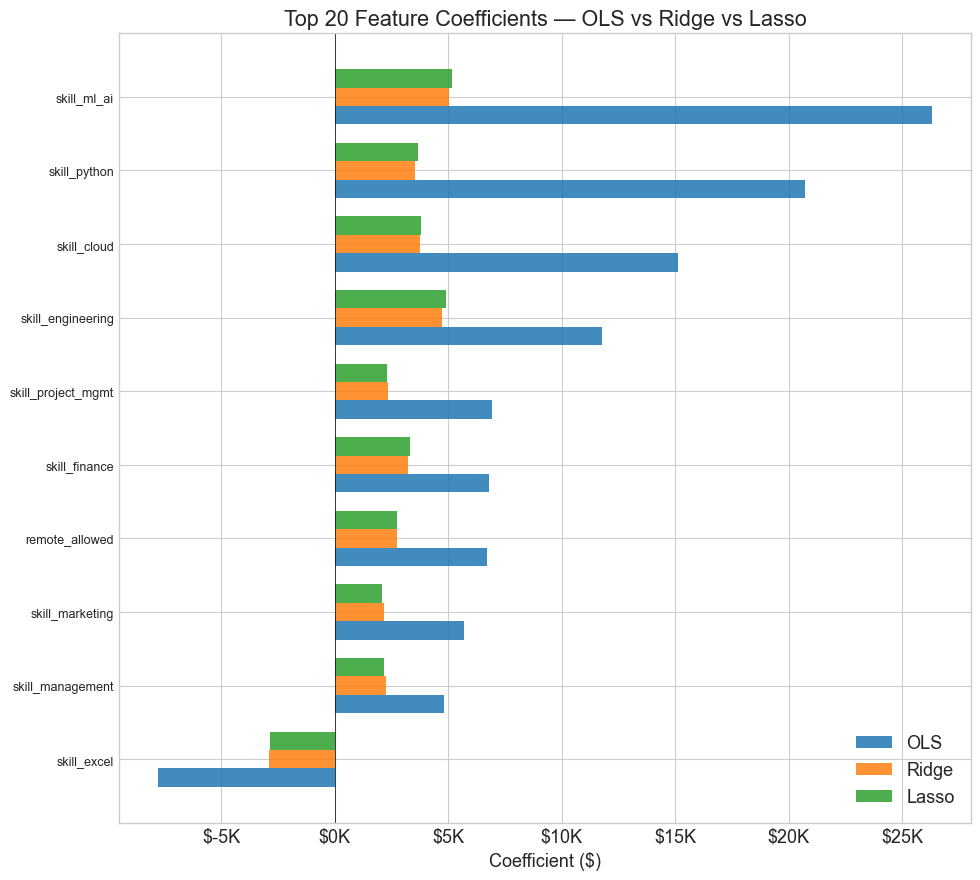

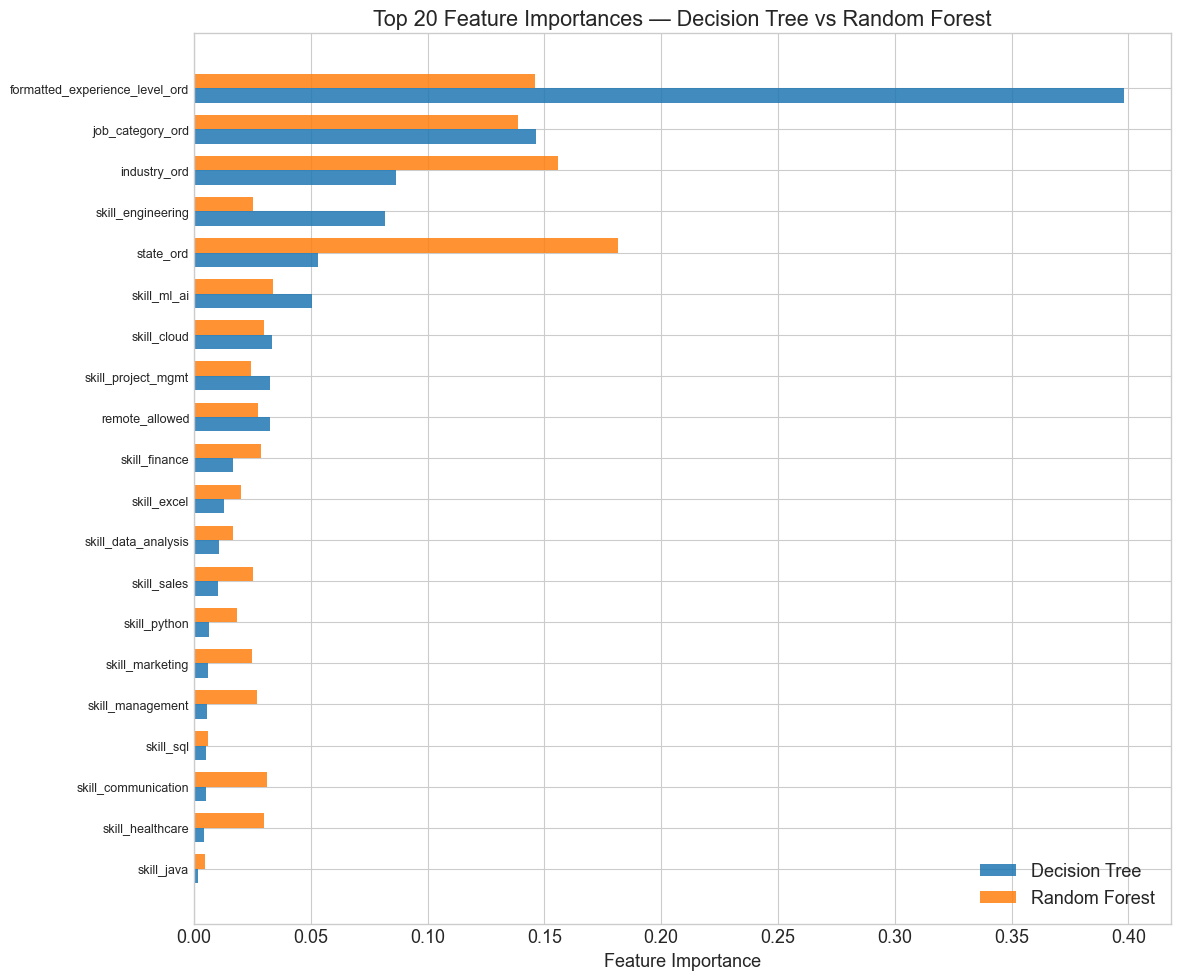


TOP 15 FEATURE IMPORTANCES: DECISION TREE vs RANDOM FOREST
                       Feature Decision Tree Random Forest  Average
                     state_ord      0.053018      0.181698 0.117358
                  industry_ord      0.086484      0.156003 0.121244
formatted_experience_level_ord      0.398348      0.145920 0.272134
              job_category_ord      0.146256      0.138688 0.142472
                   skill_ml_ai      0.050644      0.033591 0.042118
                   skill_cloud      0.033468      0.030008 0.031738
                 skill_finance      0.016522      0.028664 0.022593
                remote_allowed      0.032384      0.027348 0.029866
             skill_engineering      0.081873      0.025295 0.053584
                   skill_sales      0.010096      0.025037 0.017567
               skill_marketing      0.006139      0.024789 0.015464
            skill_project_mgmt      0.032610      0.024412 0.028511
                   skill_excel      0.012865      0.0202

In [141]:
# ============================================================================
# VISUALIZATION 1: Linear Model Coefficients (OLS, Ridge, Lasso)
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 9))
top_n = 10
# Filter out Intercept row which has NaN values for Ridge/Lasso
top = coef_df_sorted[coef_df_sorted['Feature'] != 'Intercept'].head(top_n).sort_values('OLS Coef ($)')
y_pos = np.arange(len(top))
w = 0.25

ax.barh(y_pos - w, top['OLS Coef ($)'], height=w, label='OLS', alpha=0.85)
ax.barh(y_pos, top['Ridge ($)'], height=w, label='Ridge', alpha=0.85)
ax.barh(y_pos + w, top['Lasso ($)'], height=w, label='Lasso', alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(top['Feature'], fontsize=9)
ax.set_xlabel('Coefficient ($)')
ax.set_title('Top 20 Feature Coefficients — OLS vs Ridge vs Lasso')
ax.legend(loc='lower right')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('coefficients_linear.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# VISUALIZATION 2: Tree-Based Model Feature Importances
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 10))
top_n = 20
top_dt = dt_importances.head(top_n).sort_values('Importance')
y_pos = np.arange(len(top_dt))
w = 0.35

# Get corresponding Random Forest importances for the same features
rf_imp_values = [rf_importances[rf_importances['Feature'] == feat]['Importance'].values[0] 
                 if feat in rf_importances['Feature'].values else 0 
                 for feat in top_dt['Feature']]

ax.barh(y_pos - w/2, top_dt['Importance'].values, height=w, label='Decision Tree', alpha=0.85)
ax.barh(y_pos + w/2, rf_imp_values, height=w, label='Random Forest', alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_dt['Feature'], fontsize=9)
ax.set_xlabel('Feature Importance')
ax.set_title('Top 20 Feature Importances — Decision Tree vs Random Forest')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('coefficients_tree.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# VISUALIZATION 3: Feature Importance Comparison Table
# ============================================================================
print("\n" + "="*100)
print("TOP 15 FEATURE IMPORTANCES: DECISION TREE vs RANDOM FOREST")
print("="*100)

# Create comparison dataframe
comp_df = pd.DataFrame({
    'Feature': dt_importances.head(15)['Feature'].values,
    'Decision Tree': dt_importances.head(15)['Importance'].values
})

# Add Random Forest importances
comp_df['Random Forest'] = comp_df['Feature'].apply(
    lambda f: rf_importances[rf_importances['Feature'] == f]['Importance'].values[0]
    if f in rf_importances['Feature'].values else 0
)

# Calculate average importance
comp_df['Average'] = (comp_df['Decision Tree'] + comp_df['Random Forest']) / 2
comp_df = comp_df.sort_values('Random Forest', ascending=False)

# Format for display
display_df = comp_df.copy()
for col in ['Decision Tree', 'Random Forest', 'Average']:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.6f}')

print(display_df.to_string(index=False))

print("\n" + "="*100)
print("FEATURE IMPORTANCE SUMMARY BY MODEL TYPE")
print("="*100)
print(f"Decision Tree:  Top feature is '{dt_importances.iloc[0]['Feature']}' with importance {dt_importances.iloc[0]['Importance']:.6f}")
print(f"Random Forest:  Top feature is '{rf_importances.iloc[0]['Feature']}' with importance {rf_importances.iloc[0]['Importance']:.6f}")

# Calculate feature importance correlation between models
common_features = set(dt_importances['Feature']) & set(rf_importances['Feature'])
if len(common_features) > 0:
    dt_common = dt_importances[dt_importances['Feature'].isin(common_features)].set_index('Feature').loc[list(common_features), 'Importance']
    rf_common = rf_importances[rf_importances['Feature'].isin(common_features)].set_index('Feature').loc[list(common_features), 'Importance']
    correlation = dt_common.corr(rf_common)
    print(f"\nImportance Correlation (DT vs RF): {correlation:.4f}")
    print("  (1.0 = perfect agreement, -1.0 = perfect disagreement, 0 = no correlation)")


## 6. Feature Importance

### 6.1 SHAP Summary Plot

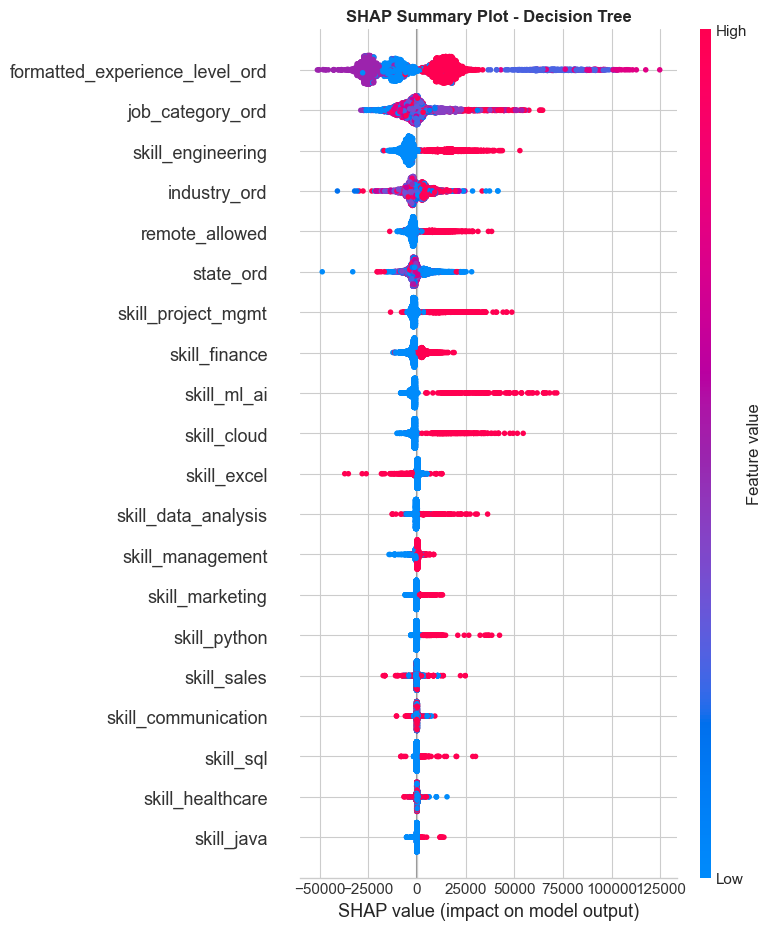

In [142]:
# use shap to explain decision tree predictions
import shap

# visualize SHAP summary plot for Decision Tree
explainer_dt = shap.TreeExplainer(dt_grid.best_estimator_)
shap_values_dt = explainer_dt.shap_values(X_test_ord)
shap.summary_plot(shap_values_dt, X_test_ord, feature_names=feature_names_ord, show=False)
plt.title('SHAP Summary Plot - Decision Tree', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_dt.png', dpi=150, bbox_inches='tight')
plt.show()

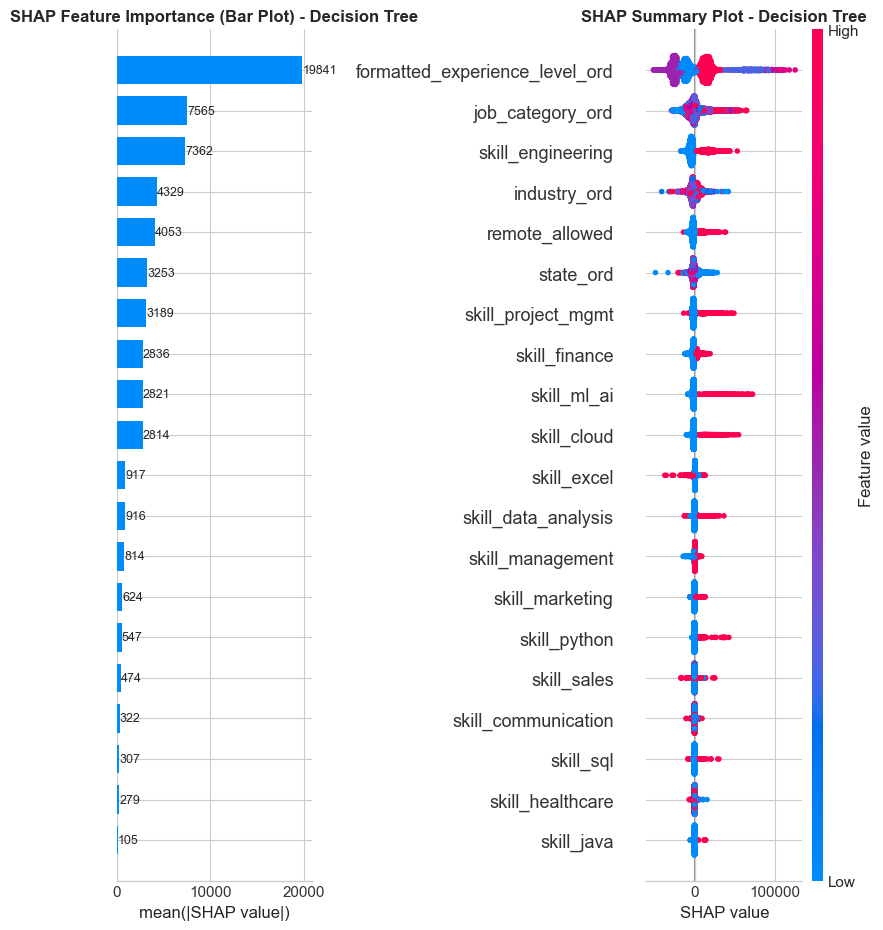

In [143]:
# visualize SHAP summary plot and SHAP bar plot for Decision Tree, left is bar plot and right is the summary plot

fig = plt.figure(figsize=(16, 10))

# SHAP bar plot (left)
plt.subplot(1, 2, 1)
shap.summary_plot(shap_values_dt, X_test_ord, feature_names=feature_names_ord, plot_type='bar', show=False)
ax = plt.gca()
# ax.invert_xaxis()
ax.set_yticklabels([])
ax.set_xlabel("mean(|SHAP value|)", fontsize=12)
# add label to the left of each bar with the shap importance value
for i, bar in enumerate(ax.patches):
    value = bar.get_width()
    ax.text(value, bar.get_y() + bar.get_height()/2, f'{value:.0f}', va='center', ha='left', fontsize=9)
plt.title('SHAP Feature Importance (Bar Plot) - Decision Tree', fontsize=12, fontweight='bold')

# SHAP summary plot (right)
plt.subplot(1, 2, 2)
shap.summary_plot(shap_values_dt, X_test_ord, feature_names=feature_names_ord, show=False)
ax = plt.gca()
ax.set_xlabel("SHAP value", fontsize=12)
plt.title('SHAP Summary Plot - Decision Tree', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 6.2 Most Accurate Sample - SHAP Waterfall Plot

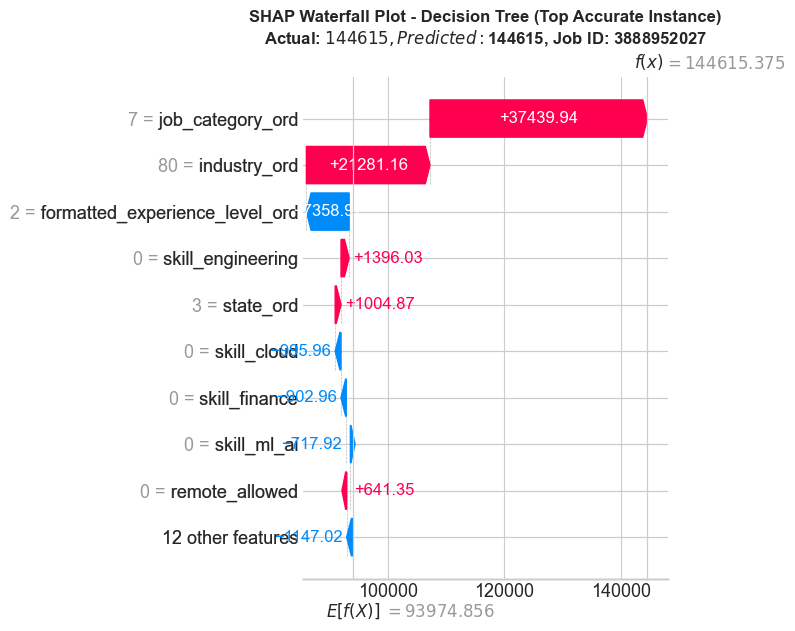

In [144]:
# visualize SHAP waterfall plot for Decision Tree
explainer_dt = shap.TreeExplainer(dt_grid.best_estimator_)
shap_values_dt = explainer_dt(X_test_ord)

# find the top accurate predictions from the Decision Tree model
dt_test_results = pd.DataFrame({
    'Index': np.arange(len(y_test), dtype=int), # index is for shap value retrieval so must be int
    'Actual': y_test,
    'Predicted': dt_preds,
    'Absolute Error': np.abs(y_test - dt_preds)
}).sort_values('Absolute Error')

# get all result from the Decision Tree model
dt_train_results = pd.DataFrame({
    'Index': np.arange(len(y_train), dtype=int), # index is for shap value retrieval so must be int
    'Actual': y_train,
    'Predicted': dt_grid.predict(X_train_ord),
    'Absolute Error': np.abs(y_train - dt_grid.predict(X_train_ord))
})
dt_train_test_results = pd.concat([dt_train_results, dt_test_results], ignore_index=False)

# Get the index of the test instance with the most accurate prediction (smallest absolute error)
top_instance_idx = int(dt_test_results.iloc[0]['Index'])

shap.plots.waterfall(shap_values_dt[int(top_instance_idx)], show=False)
# add the actual vs predicted values in the title
actual_val = dt_test_results.iloc[0]['Actual']
pred_val = dt_test_results.iloc[0]['Predicted']
# add the job id to the title, which is from df_ft['job_id'] and corresponds to the index of X_test_ord
top_job_id = df_ft.loc[X_test_ord.index[top_instance_idx], 'job_id']
plt.title(f'SHAP Waterfall Plot - Decision Tree (Top Accurate Instance)\nActual: ${actual_val:.0f}, Predicted: ${pred_val:.0f}, Job ID: {top_job_id}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_dt.png', dpi=150, bbox_inches='tight')
plt.show()

In [145]:
df_ft[df_ft['job_id'] == top_job_id][['job_id', 'title', 'description', 'normalized_salary', 'salary_adjusted']]

,job_id,title,description,normalized_salary,salary_adjusted
3582,3888952027,Associate Veterinarian,North Kenilworth Veterinary Center is currentl...,135000.0,144615.375


In [146]:
df_ft[df_ft['title'].str.contains('Veterinarian', case=False)][['job_id','company_name', 'title', 'description', 'normalized_salary', 'salary_adjusted']].merge(dt_train_test_results, left_index=True, right_index=True)[['job_id', 'title', 'description', 'normalized_salary', 'salary_adjusted', 'Actual', 'Predicted', 'Absolute Error']]

,job_id,title,description,normalized_salary,salary_adjusted,Actual,Predicted,Absolute Error
2822,3887887956,Associate Veterinarian,Animal Hospital and Emergency Clinic of Conroe...,127500.0,136581.18750,136581.18750,122548.140000,14033.047500
2830,3887888958,Associate Veterinarian,Cross Creek Veterinary Hospital has an opening...,117500.0,125868.93750,125868.93750,122548.140000,3320.797500
2845,3887891790,Associate Veterinarian,Babcock Hills Veterinary Hospital is a full-se...,110000.0,117834.75000,117834.75000,122548.140000,4713.390000
2857,3887893576,Mixed Animal Practice Veterinarian,Catlett Animal Hospital has anopportunity for ...,100000.0,107122.50000,107122.50000,103965.599925,3156.900075
2859,3887893591,GP Veterinarian,Uptown Animal Hospitalis looking to welcome aF...,125000.0,133903.12500,133903.12500,131950.924560,1952.200440
3560,3888946667,Associate Veterinarian,The Pet Stop is a well-established small anima...,175000.0,187464.37500,187464.37500,144615.375000,42849.000000
3566,3888947591,Associate Veterinarian,Cross Creek Veterinary Hospital has an opening...,117500.0,125868.93750,125868.93750,122548.140000,3320.797500
3582,3888952027,Associate Veterinarian,North Kenilworth Veterinary Center is currentl...,135000.0,144615.37500,144615.37500,144615.375000,0.000000
3583,3888952028,Associate Veterinarian,All Creatures Veterinary Clinic is a multi-doc...,175000.0,187464.37500,187464.37500,144615.375000,42849.000000
3588,3888953086,Relief Veterinarian,Lakefield Veterinary Group is currently seekin...,145600.0,155970.36000,155970.36000,144615.375000,11354.985000


### 6.3 Top 100 Most Accurate Sample - Job Category Distribution

In [147]:
dt_test_results.merge(df_ft[['job_id', 'title', 'description', 'normalized_salary', 'salary_adjusted', 'job_category']], left_index=True, right_index=True)[['job_id', 'title', 'description', 'normalized_salary','job_category', 'salary_adjusted', 'Actual', 'Predicted', 'Absolute Error']].sort_values('Absolute Error').head(100).value_counts('job_category')

job_category
Engineering/Trades             20
Other                          16
Administrative                  9
Management/Director             8
Sales                           7
Healthcare/Clinical/Nursing     6
Logistics/Warehouse             6
Software/Dev/IT/DevOps          6
Data/ML/Analyst                 6
Finance/Accounting              5
Retail/Customer Service         3
Marketing                       3
Project Management              2
Hospitality/Food                1
Legal                           1
HR/Recruiting                   1
Name: count, dtype: int64

### 6.4 Least Accurate Sample - SHAP Waterfall Plot

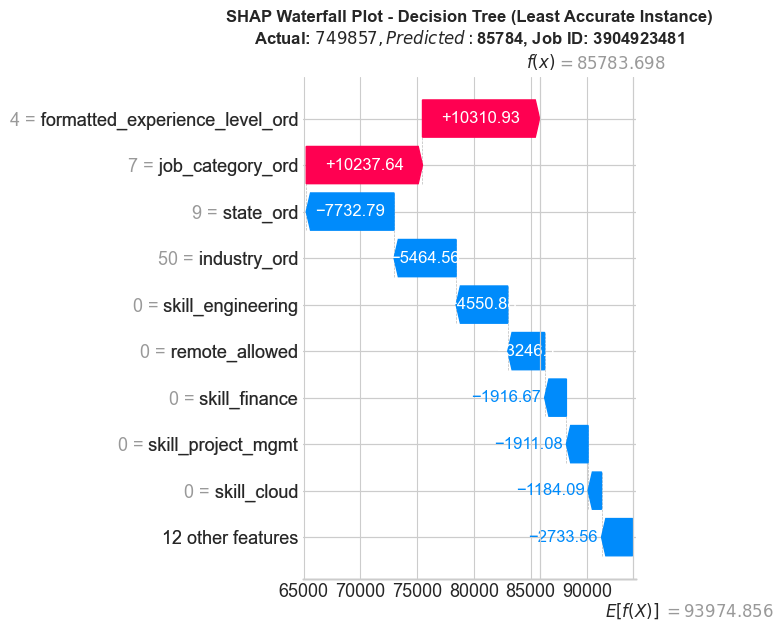

In [148]:
# for least accurate prediction (largest absolute error), draw shap waterfall plot
least_instance_idx = int(dt_test_results.iloc[-1]['Index'])
shap.plots.waterfall(shap_values_dt[int(least_instance_idx)], show=False)
# add the actual vs predicted values in the title
actual_val = dt_test_results.iloc[-1]['Actual']
pred_val = dt_test_results.iloc[-1]['Predicted']
# add the job id to the title, which is from df_ft['job_id'] and corresponds to the index of X_test_ord
least_job_id = df_ft.loc[X_test_ord.index[least_instance_idx], 'job_id']
plt.title(f'SHAP Waterfall Plot - Decision Tree (Least Accurate Instance)\nActual: ${actual_val:.0f}, Predicted: ${pred_val:.0f}, Job ID: {least_job_id}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_dt_least.png', dpi=150, bbox_inches='tight')
plt.show()

In [149]:
df_ft[df_ft['job_id'] == least_job_id][['title', 'description', 'normalized_salary', 'salary_adjusted']]

,title,description,normalized_salary,salary_adjusted
18369,Oral Surgeon,Overview\n\nAre you a skilled and passionate o...,700000.0,749857.5


In [150]:
df_ft[df_ft['title'].str.contains('Surgeon', case=False)][['job_id','company_name', 'title', 'description', 'normalized_salary', 'salary_adjusted']].merge(dt_train_test_results, left_index=True, right_index=True)[['job_id', 'title', 'description', 'normalized_salary', 'salary_adjusted', 'Actual', 'Predicted', 'Absolute Error']]

,job_id,title,description,normalized_salary,salary_adjusted,Actual,Predicted,Absolute Error
2846,3887891803,Surgeon,"Veterinary Trauma Surgeon, Entrepreneur, and V...",225000.0,241025.625000,241025.625000,103965.599925,137060.025075
4868,3891079222,Colorectal Surgeon,Boone Health has been named one of America's 1...,425000.0,455270.625000,455270.625000,95339.025000,359931.600000
6772,3895543799,Oral Surgeon - DDS/DMD,"At Aspen Dental, we put you first, so you can ...",750000.0,803418.750000,803418.750000,103965.599925,699453.150075
7385,3898162608,Orthopedic Surgeon,Job Description & Requirements\n\nOrthopedic S...,680000.0,728433.000000,728433.000000,116810.658900,611622.341100
16314,3904096276,Associate Plastic Surgeon,About AscendAscend Plastic Surgery Partners is...,312500.0,334757.812500,334757.812500,116810.658900,217947.153600
18351,3904921870,Oral Surgeon,Overview\n\nAre you a skilled and passionate O...,625000.0,669515.625000,669515.625000,103965.599925,565550.025075
18369,3904923481,Oral Surgeon,Overview\n\nAre you a skilled and passionate o...,700000.0,749857.500000,749857.500000,85783.698000,664073.802000
18376,3904924457,Oral Surgeon,Overview\n\nAre you a skilled and compassionat...,600000.0,642735.000000,642735.000000,103965.599925,538769.400075
18419,3904927329,Oral Surgeon,Overview\n\nAre you a skilled and dedicated or...,625000.0,669515.625000,669515.625000,85698.000000,583817.625000
18428,3904928122,Oral Surgeon,Overview\n\nAre you a skilled and passionate O...,625000.0,669515.625000,669515.625000,85783.698000,583731.927000


### 6.5 Least 100 Most Accurate Sample - Job Category Distribution

In [151]:
dt_test_results.merge(df_ft[['job_id', 'title', 'description', 'normalized_salary', 'salary_adjusted', 'job_category']], left_index=True, right_index=True)[['job_id', 'title', 'description', 'normalized_salary','job_category', 'salary_adjusted', 'Actual', 'Predicted', 'Absolute Error']].sort_values('Absolute Error').tail(100).value_counts('job_category')

job_category
Other                          23
Healthcare/Clinical/Nursing    22
Management/Director            16
Sales                          10
Finance/Accounting              9
Engineering/Trades              7
Marketing                       3
Legal                           3
Administrative                  3
Software/Dev/IT/DevOps          3
Product/Design/UX               1
Name: count, dtype: int64

### 6.6 MAPE by Job Category

In [152]:
# Give the model MAPE on each Job Category and rank them by MAPE on test dataset
test_results_with_cat = dt_test_results.merge(X_test[['job_category']], left_index=True, right_index=True)
mape_by_category = test_results_with_cat.groupby('job_category').apply(lambda df: np.mean(np.abs((df['Actual'] - df['Predicted']) / df['Actual'])) * 100).sort_values()
# merge with the count of each category in the test set
category_counts = test_results_with_cat['job_category'].value_counts()
mape_by_category_with_counts = mape_by_category.to_frame().merge(category_counts.to_frame(), left_index=True, right_index=True, how='left')
mape_by_category_with_counts.columns = ['MAPE', 'Count']
mape_by_category_with_counts

,MAPE,Count
job_category,,
Data/ML/Analyst,26.027899,257
Hospitality/Food,26.094144,39
Project Management,28.693443,102
Marketing,28.787498,84
Finance/Accounting,29.085268,404
HR/Recruiting,29.173672,83
Software/Dev/IT/DevOps,30.112674,180
Administrative,30.552585,402
Logistics/Warehouse,31.113109,101


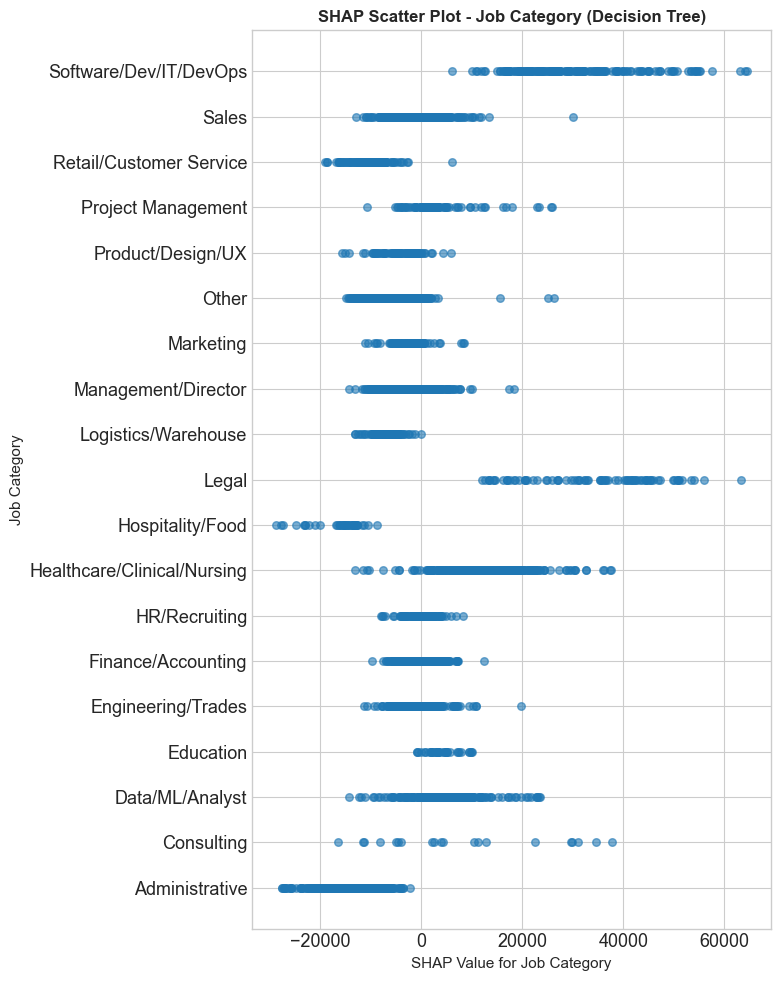

In [153]:
# Using scatter plot with switched axes - Job Category on Y-axis, Salary SHAP values on X-axis
job_category_idx = feature_names_ord.index('job_category_ord')

# Get the actual job_category_ord values from the test data
job_category_col_idx = categorical_cols.index('job_category')
job_categories = ord_enc.categories_[job_category_col_idx]
job_cat_ord_values = X_test_ord.iloc[:, job_category_col_idx].values
unique_ord_values = np.sort(np.unique(job_cat_ord_values))

# Get SHAP values
shap_values = shap_values_dt[:, job_category_idx].values
base_values = shap_values_dt.base_values

# Create scatter plot with switched axes
plt.figure(figsize=(8, 10))
plt.scatter(shap_values, job_cat_ord_values, alpha=0.6, s=30)
plt.title('SHAP Scatter Plot - Job Category (Decision Tree)', fontsize=12, fontweight='bold')
plt.xlabel('SHAP Value for Job Category', fontsize=11)
plt.ylabel('Job Category', fontsize=11)

# Set y-axis ticks and labels based on actual ordinal values
tick_labels = [job_categories[int(val)] for val in unique_ord_values]
ax = plt.gca()
ax.set_yticks(unique_ord_values)
ax.set_yticklabels(tick_labels, rotation=0, ha='right')

plt.tight_layout()
plt.savefig('shap_scatter_job_category_dt.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.7 MAPE by level experience

In [154]:
# Give the model MAPE on each experience level and rank them by MAPE on test dataset
test_results_with_level = dt_test_results.merge(X_test[['formatted_experience_level']], left_index=True, right_index=True)
mape_by_level = test_results_with_level.groupby('formatted_experience_level').apply(lambda df: np.mean(np.abs((df['Actual'] - df['Predicted']) / df['Actual'])) * 100).sort_values()
# merge with the count of each experience level in the test set
level_counts = test_results_with_level['formatted_experience_level'].value_counts()
mape_by_level_with_counts = mape_by_level.to_frame().merge(level_counts.to_frame(), left_index=True, right_index=True, how='left')
mape_by_level_with_counts.columns = ['MAPE', 'Count']
mape_by_level_with_counts

,MAPE,Count
formatted_experience_level,,
Entry level,29.350968,1313
Director,32.909278,229
Associate,33.547295,1326
Mid-Senior level,34.579968,1857
Executive,38.070142,51


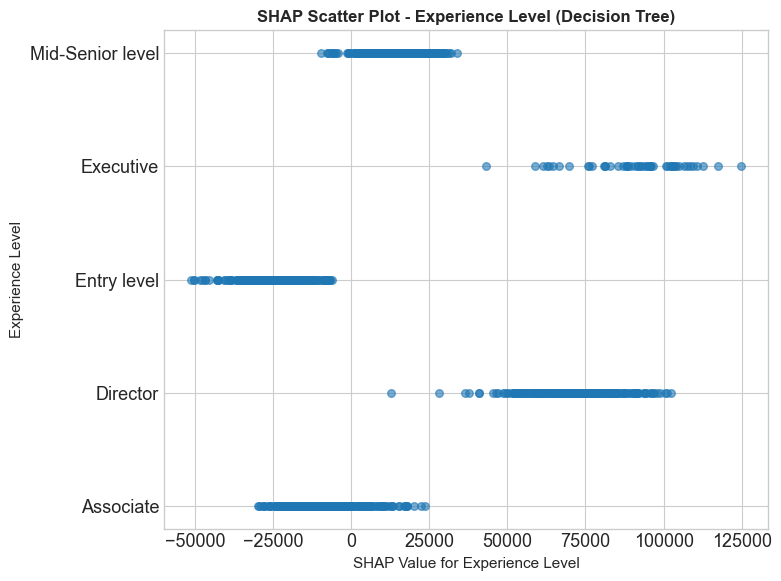

In [155]:
# Using scatter plot with switched axes - Experience Level on Y-axis, Salary SHAP values on X-axis
experience_level_idx = feature_names_ord.index('formatted_experience_level_ord')

# Get the actual formatted_experience_level_ord values from the test data
experience_level_col_idx = categorical_cols.index('formatted_experience_level')
experience_levels = ord_enc.categories_[experience_level_col_idx]
exp_level_ord_values = X_test_ord.iloc[:, experience_level_col_idx].values
unique_exp_ord_values = np.sort(np.unique(exp_level_ord_values))

# Get SHAP values
shap_values_exp = shap_values_dt[:, experience_level_idx].values

# Create scatter plot with switched axes
plt.figure(figsize=(8, 6))
plt.scatter(shap_values_exp, exp_level_ord_values, alpha=0.6, s=30)
plt.title('SHAP Scatter Plot - Experience Level (Decision Tree)', fontsize=12, fontweight='bold')
plt.xlabel('SHAP Value for Experience Level', fontsize=11)
plt.ylabel('Experience Level', fontsize=11)

# Set y-axis ticks and labels based on actual ordinal values
exp_tick_labels = [experience_levels[int(val)] for val in unique_exp_ord_values]
ax = plt.gca()
ax.set_yticks(unique_exp_ord_values)
ax.set_yticklabels(exp_tick_labels, rotation=0, ha='right')

plt.tight_layout()
plt.savefig('shap_scatter_experience_level_dt.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Visualize Model

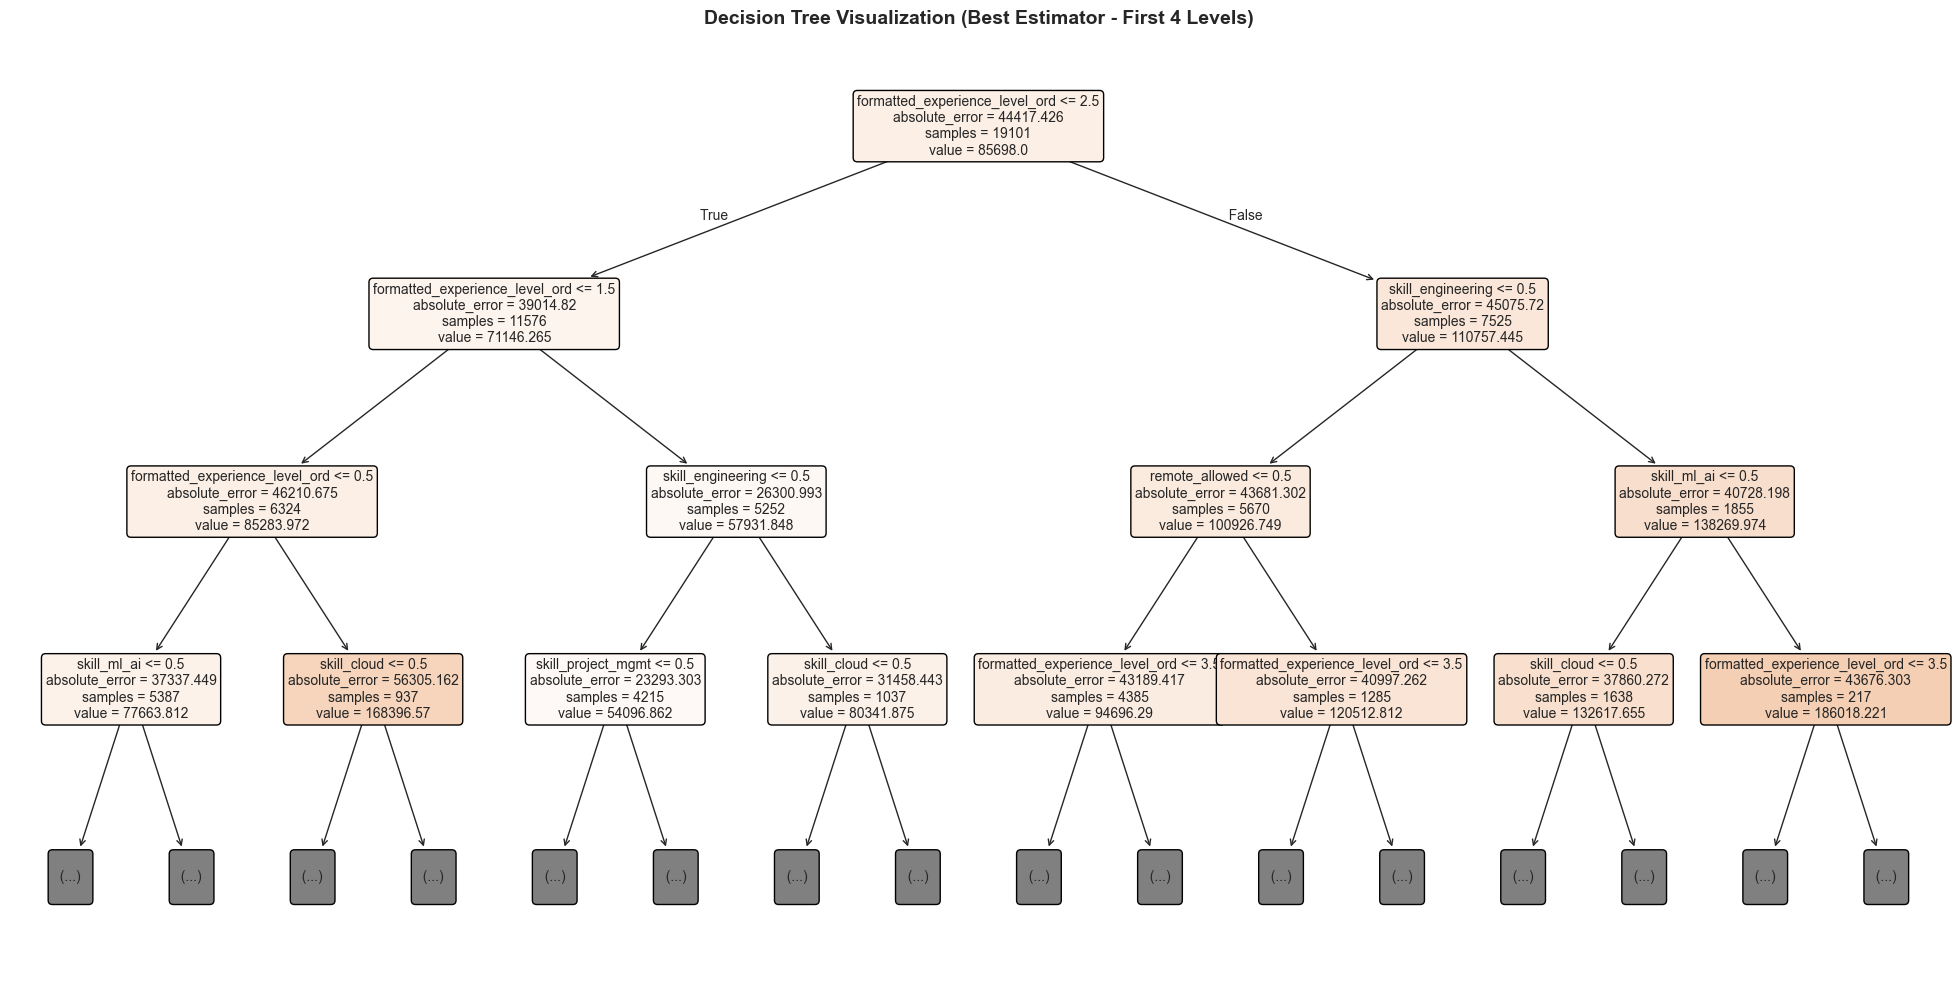

Decision Tree visualization created successfully!


In [163]:
# Visualize best Decision Tree using sklearn's tree plotting
from sklearn import tree
import matplotlib.pyplot as plt

# Get the best Decision Tree estimator
best_dt = dt_grid.best_estimator_

# Create visualization using sklearn - limit to first 4 levels
fig, ax = plt.subplots(figsize=(20, 10))
tree.plot_tree(best_dt, 
               feature_names=feature_names_ord,
               filled=True,
               rounded=True,
               fontsize=10,
               max_depth=3,  # Show only first 4 levels (0-3)
               ax=ax)
plt.title('Decision Tree Visualization (Best Estimator - First 4 Levels)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# plt.savefig('decision_tree_visualization.png', dpi=150, bbox_inches='tight')
fig.savefig('decision_tree_visualization.png', dpi=150, bbox_inches='tight')
print("Decision Tree visualization created successfully!")

## 8. Model Comparison

_Feedback: "MAPE or RMSE is good one... R² is NOT ideal, consider to just report it but not to use it as a target."_

**MAPE** is our primary metric. R² is reported for reference only.

In [157]:
summary = pd.DataFrame([{
    'Model': r['Model'],
    'RMSE': f"${r['RMSE']:,.0f}",
    'MAE': f"${r['MAE']:,.0f}",
    '⭐ MAPE': f"{r['MAPE']:.1f}%",
    'R² (ref)': f"{r['R2']:.3f}"
} for r in results])

print("MODEL COMPARISON — Primary metric: MAPE")
print("="*80)
display(summary)

best_idx = np.argmin([r['MAPE'] for r in results])
print(f"\n✅ Best model: {results[best_idx]['Model']} (MAPE = {results[best_idx]['MAPE']:.1f}%)")
improvement = results[0]['MAPE'] - results[best_idx]['MAPE']
print(f"   Improvement over baseline: {improvement:.1f} percentage points")

MODEL COMPARISON — Primary metric: MAPE


,Model,RMSE,MAE,⭐ MAPE,R² (ref)
0,Baseline (Median),"$64,235","$44,707",48.1%,-0.074
1,OLS Linear Regression,"$46,819","$31,069",35.9%,0.429
2,Ridge (α=1151),"$46,840","$31,071",36.0%,0.429
3,Lasso (α=115),"$46,767","$31,002",35.9%,0.431
4,Decision Tree (depth=15),"$50,640","$32,015",32.8%,0.332
5,Random Forest (n_est=250),"$47,001","$30,142",34.0%,0.425



✅ Best model: Decision Tree (depth=15) (MAPE = 32.8%)
   Improvement over baseline: 15.3 percentage points


<Figure size 640x480 with 0 Axes>

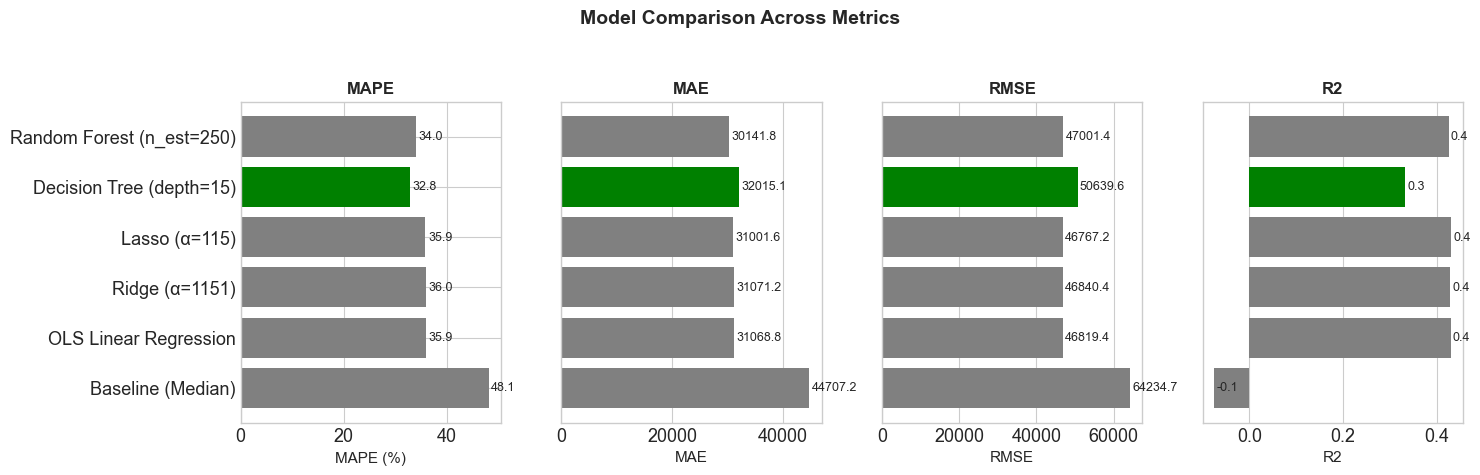

In [158]:
# Visualize the model comparison for each metric using histogram (horizontal bar) with best model highlighted in green and others in gray using results
# label the MAPE value to the right of the bar, order the Decision Tree on the top, then Random Forest, then OLS, Ridge, Lasso, and Baseline on the buttom
# only show the y axis label on the first graph

metrics = ['MAPE', 'MAE', 'RMSE', 'R2']
fig, axes = plt.subplots(1, len(metrics), figsize=(15, 5))
for i, metric in enumerate(metrics):
    values = [float(r[metric]) for r in results]
    bars = axes[i].barh([r['Model'] for r in results], values, color=['green' if idx == best_idx else 'gray' for idx in range(len(results))])
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    if metric == 'MAPE':
        axes[i].set_xlabel(f'{metric} (%)', fontsize=11)
    else:
        axes[i].set_xlabel(metric, fontsize=11)
    if i > 0:
        axes[i].set_yticks([])
    # Add value labels to the right of the bars
    for bar, value in zip(bars, values):
        axes[i].text(bar.get_width() + (0.01 * max(values)), bar.get_y() + bar.get_height()/2, f'{value:.1f}', va='center', fontsize=9)
plt.suptitle('Model Comparison Across Metrics', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('model_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Predicted Salary Range with Confidence

Instead of a point prediction, we output a **salary range** using residual-based confidence intervals.

In [159]:
# Prepare predictions for multiple models
models_to_analyze = [
    ('OLS', ols_preds),
    ('Ridge', ridge_preds),
    ('Lasso', lasso_preds),
    ('Decision Tree', dt_preds),
    ('Random Forest', rf_preds)
]

print("PREDICTED SALARY RANGE WITH CONFIDENCE INTERVALS")
print("="*100)

# 80% CI (±1.28σ) and 90% CI (±1.645σ)
z_80, z_90 = 1.28, 1.645

results_ci = []

for model_name, preds in models_to_analyze:
    residuals = y_test.values - preds
    residual_std = np.std(residuals)
    
    # Calculate confidence intervals
    lo_80 = np.maximum(preds - z_80 * residual_std, 0)
    hi_80 = preds + z_80 * residual_std
    lo_90 = np.maximum(preds - z_90 * residual_std, 0)
    hi_90 = preds + z_90 * residual_std
    
    # Calculate coverage
    cov_80 = np.mean((y_test.values >= lo_80) & (y_test.values <= hi_80)) * 100
    cov_90 = np.mean((y_test.values >= lo_90) & (y_test.values <= hi_90)) * 100
    
    results_ci.append({
        'Model': model_name,
        'Residual Std Dev': f'${residual_std:,.0f}',
        '80% CI Range': f'±${z_80 * residual_std:,.0f}',
        '80% Coverage': f'{cov_80:.1f}%',
        '90% CI Range': f'±${z_90 * residual_std:,.0f}',
        '90% Coverage': f'{cov_90:.1f}%'
    })

ci_df = pd.DataFrame(results_ci)
display(ci_df)

PREDICTED SALARY RANGE WITH CONFIDENCE INTERVALS


,Model,Residual Std Dev,80% CI Range,80% Coverage,90% CI Range,90% Coverage
0,OLS,"$46,819","±$59,928",88.6%,"±$77,017",93.7%
1,Ridge,"$46,840","±$59,955",88.8%,"±$77,052",93.8%
2,Lasso,"$46,767","±$59,862",88.6%,"±$76,931",93.7%
3,Decision Tree,"$49,939","±$63,922",87.4%,"±$82,150",92.6%
4,Random Forest,"$47,001","±$60,161",87.9%,"±$77,317",93.2%


In [160]:
# ============================================================================
# ACTUAL vs PREDICTED VALUES FOR EACH MODEL
# ============================================================================
print("\nACTUAL vs PREDICTED SALARY FOR 10 SAMPLE TEST CASES")
print("="*100)

sample_idx = np.random.RandomState(42).choice(len(y_test), 10, replace=False)

# Create a DataFrame with actual values and predictions from all models
pred_comparison = pd.DataFrame({
    'Sample #': range(1, 11),
    'Actual Salary': [y_test.iloc[i] for i in sample_idx]
})

# Add predictions from each model
for model_name, preds in models_to_analyze:
    pred_comparison[f'{model_name}'] = [preds[i] for i in sample_idx]

# Format for display
pred_display = pred_comparison.copy()
for col in pred_display.columns:
    if col != 'Sample #':
        pred_display[col] = pred_display[col].apply(lambda x: f'${x:,.0f}')

display(pred_display)

# ============================================================================
# PREDICTION ERRORS FOR EACH MODEL
# ============================================================================
print("\n" + "="*100)
print("PREDICTION ERRORS (Predicted - Actual) FOR 10 SAMPLES")
print("="*100)

error_comparison = pd.DataFrame({
    'Sample #': range(1, 11),
    'Actual': [y_test.iloc[i] for i in sample_idx]
})

# Calculate errors for each model
for model_name, preds in models_to_analyze:
    errors = [preds[i] - y_test.iloc[i] for i in sample_idx]
    error_comparison[f'{model_name}'] = errors

# Format for display (show absolute errors and percentage errors)
error_display = error_comparison.copy()
error_display_abs = error_display.copy()
for model_name, _ in models_to_analyze:
    error_display_abs[f'{model_name}'] = error_display_abs[f'{model_name}'].apply(lambda x: f'${x:+,.0f}')

display(error_display_abs)

# Show MAPE for each model on these samples
print("\n" + "="*100)
print("MEAN ABSOLUTE PERCENTAGE ERROR (MAPE) FOR EACH MODEL")
print("="*100)

mape_results = []
for model_name, preds in models_to_analyze:
    sample_preds = [preds[i] for i in sample_idx]
    sample_actuals = [y_test.iloc[i] for i in sample_idx]
    mape = np.mean(np.abs((np.array(sample_actuals) - np.array(sample_preds)) / np.array(sample_actuals))) * 100
    mape_results.append({
        'Model': model_name,
        'MAPE (10 samples)': f'{mape:.2f}%',
        'Avg Prediction': f'${np.mean(sample_preds):,.0f}',
        'Avg Actual': f'${np.mean(sample_actuals):,.0f}'
    })

mape_df = pd.DataFrame(mape_results)
display(mape_df)



ACTUAL vs PREDICTED SALARY FOR 10 SAMPLE TEST CASES


,Sample #,Actual Salary,OLS,Ridge,Lasso,Decision Tree,Random Forest
0,1,"$144,618","$88,733","$88,839","$89,660","$106,951","$121,165"
1,2,"$100,160","$94,465","$95,981","$94,239","$80,288","$70,294"
2,3,"$126,297","$114,784","$113,857","$113,915","$93,218","$110,470"
3,4,"$82,752","$90,415","$91,801","$93,737","$102,321","$121,125"
4,5,"$107,122","$124,452","$124,294","$124,470","$56,127","$107,444"
5,6,"$115,157","$107,450","$108,337","$105,846","$80,288","$99,632"
6,7,"$38,993","$59,261","$60,508","$59,048","$46,791","$54,505"
7,8,"$53,476","$72,690","$73,260","$72,047","$80,342","$104,796"
8,9,"$163,241","$67,709","$68,893","$68,967","$40,107","$67,838"
9,10,"$64,273","$80,131","$80,829","$80,400","$66,952","$70,986"



PREDICTION ERRORS (Predicted - Actual) FOR 10 SAMPLES


,Sample #,Actual,OLS,Ridge,Lasso,Decision Tree,Random Forest
0,1,144617.945940,"$-55,885","$-55,779","$-54,958","$-37,667","$-23,453"
1,2,100159.537500,"$-5,695","$-4,179","$-5,921","$-19,871","$-29,865"
2,3,126297.427500,"$-11,513","$-12,440","$-12,382","$-33,079","$-15,828"
3,4,82752.131250,"$+7,663","$+9,048","$+10,985","$+19,569","$+38,373"
4,5,107122.500000,"$+17,329","$+17,172","$+17,348","$-50,995",$+321
5,6,115156.687500,"$-7,707","$-6,819","$-9,311","$-34,868","$-15,525"
6,7,38992.590000,"$+20,269","$+21,515","$+20,055","$+7,799","$+15,512"
7,8,53475.552000,"$+19,215","$+19,785","$+18,572","$+26,866","$+51,320"
8,9,163241.299687,"$-95,533","$-94,348","$-94,275","$-123,135","$-95,403"
9,10,64273.500000,"$+15,857","$+16,556","$+16,126","$+2,678","$+6,712"



MEAN ABSOLUTE PERCENTAGE ERROR (MAPE) FOR EACH MODEL


,Model,MAPE (10 samples),Avg Prediction,Avg Actual
0,OLS,25.67%,"$90,009","$99,609"
1,Ridge,26.12%,"$90,660","$99,609"
2,Lasso,26.03%,"$90,233","$99,609"
3,Decision Tree,32.34%,"$75,339","$99,609"
4,Random Forest,32.34%,"$92,825","$99,609"


## 10. Cross-Validation

5-fold CV confirms that performance is consistent across data splits.

In [161]:
mape_scorer = make_scorer(
    lambda y, yp: np.mean(np.abs((y - yp) / y)) * 100,
    greater_is_better=False
)

print("5-Fold Cross-Validation — MAPE")
print("="*80)

cv_results = []

# Linear models
for name, model, data in [
    ('OLS',   LinearRegression(),                             X_train_enc),
    ('Ridge', Ridge(alpha=ridge_cv.alpha_),                   X_train_scaled),
    ('Lasso', Lasso(alpha=lasso_cv.alpha_, max_iter=10000),   X_train_scaled)
]:
    scores = -cross_val_score(model, data, y_train, cv=5, scoring=mape_scorer)
    print(f"  {name:20s}: MAPE = {scores.mean():5.1f}% ± {scores.std():4.1f}%  "
          f"(folds: {', '.join(f'{v:5.1f}%' for v in scores)})")
    cv_results.append({
        'Model': name,
        'Mean MAPE': f'{scores.mean():.1f}%',
        'Std Dev': f'{scores.std():.1f}%',
        'Fold 1': f'{scores[0]:.1f}%',
        'Fold 2': f'{scores[1]:.1f}%',
        'Fold 3': f'{scores[2]:.1f}%',
        'Fold 4': f'{scores[3]:.1f}%',
        'Fold 5': f'{scores[4]:.1f}%'
    })

# Tree-based models
for name, model, data in [
    ('Decision Tree', dt_grid.best_estimator_, X_train_ord),
    ('Random Forest', rf_grid.best_estimator_, X_train_ord)
]:
    scores = -cross_val_score(model, data, y_train, cv=5, scoring=mape_scorer)
    print(f"  {name:20s}: MAPE = {scores.mean():5.1f}% ± {scores.std():4.1f}%  "
          f"(folds: {', '.join(f'{v:5.1f}%' for v in scores)})")
    cv_results.append({
        'Model': name,
        'Mean MAPE': f'{scores.mean():.1f}%',
        'Std Dev': f'{scores.std():.1f}%',
        'Fold 1': f'{scores[0]:.1f}%',
        'Fold 2': f'{scores[1]:.1f}%',
        'Fold 3': f'{scores[2]:.1f}%',
        'Fold 4': f'{scores[3]:.1f}%',
        'Fold 5': f'{scores[4]:.1f}%'
    })

print("\n" + "="*80)
print("CROSS-VALIDATION RESULTS SUMMARY")
print("="*80)

cv_df = pd.DataFrame(cv_results)
display(cv_df)

print("\n→ Tree-based models show consistency across folds, confirming stable generalization.")


5-Fold Cross-Validation — MAPE
  OLS                 : MAPE =  36.6% ±  0.7%  (folds:  36.6%,  37.0%,  37.2%,  35.1%,  36.8%)
  Ridge               : MAPE =  36.5% ±  0.8%  (folds:  36.6%,  37.0%,  37.3%,  35.1%,  36.8%)
  Lasso               : MAPE =  36.4% ±  0.8%  (folds:  36.4%,  36.9%,  37.2%,  35.0%,  36.5%)
  Decision Tree       : MAPE =  33.2% ±  0.6%  (folds:  33.2%,  33.9%,  33.7%,  32.1%,  33.0%)
  Random Forest       : MAPE =  34.8% ±  0.6%  (folds:  35.2%,  34.9%,  35.5%,  33.6%,  34.9%)

CROSS-VALIDATION RESULTS SUMMARY


,Model,Mean MAPE,Std Dev,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
0,OLS,36.6%,0.7%,36.6%,37.0%,37.2%,35.1%,36.8%
1,Ridge,36.5%,0.8%,36.6%,37.0%,37.3%,35.1%,36.8%
2,Lasso,36.4%,0.8%,36.4%,36.9%,37.2%,35.0%,36.5%
3,Decision Tree,33.2%,0.6%,33.2%,33.9%,33.7%,32.1%,33.0%
4,Random Forest,34.8%,0.6%,35.2%,34.9%,35.5%,33.6%,34.9%



→ Tree-based models show consistency across folds, confirming stable generalization.


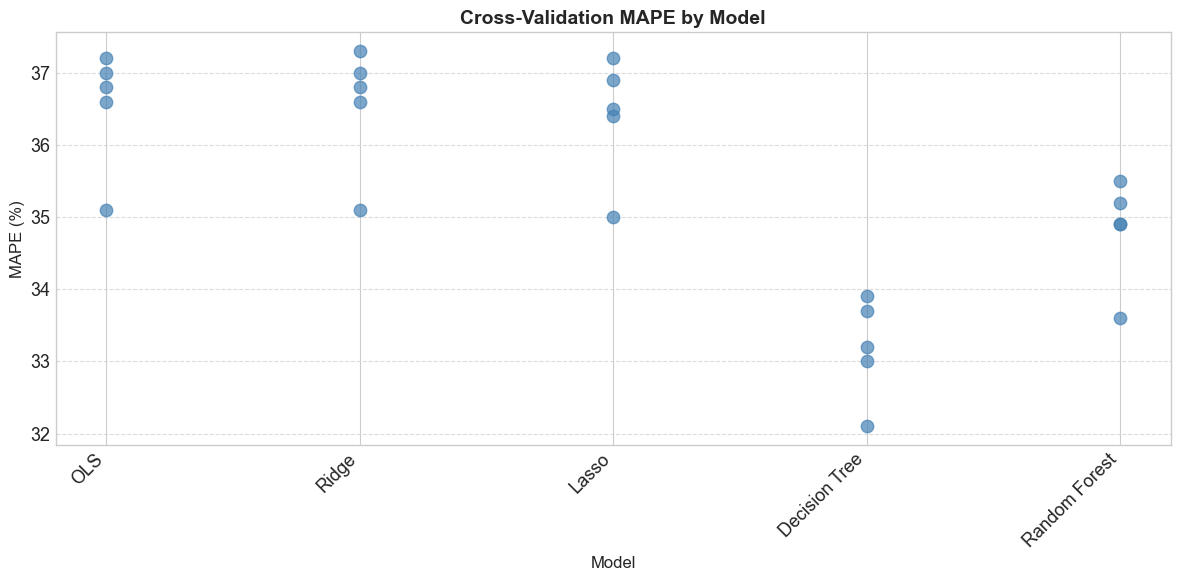

In [162]:
# Visualize model performance comparison using dot plot of MAPE across folds
model_names = [result['Model'] for result in cv_results]
fold_mapes = [[float(result[f'Fold {i}'].rstrip('%')) for i in range(1, 6)] for result in cv_results]

fig, ax = plt.subplots(figsize=(12, 6))

# Add individual fold points as scatter (dots only)
for i, (model, mapes) in enumerate(zip(model_names, fold_mapes)):
    x = [i + 1] * len(mapes)
    ax.scatter(x, mapes, color='steelblue', s=80, alpha=0.7, zorder=3)

ax.set_ylabel('MAPE (%)', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_title('Cross-Validation MAPE by Model', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, len(model_names) + 1))
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()